# 08 — Can we do better? A prototype for INFLECTIONS

**Desk request, 2026-08-12.** *"lets aim to improve performance now …
i want the get in to flag when prices do infact move upwards
significantly, and get out to call the top (quite near the tops) —
especially for larger price moments that are really retail driven.
also … perhaps can we make it so like we can try and predict price
INFLECTIONS quite well? … after a signal we get a large change in
price — regardless of direction … perhaps make it so like we can also
see qualitative (if there is an inflection, use AI to check the posts
and give a qualitative view on what is happening)."*

**This notebook changes nothing.** It reads the shipped stores, builds
its own labels and its own walk-forward, and reports. No file in
`analytics/`, `src/` or `config/` is touched — adoption, if any, is a
separate decision taken after reading this.

## The four decisions this notebook was given

| Question | Answer | Where it bites |
|---|---|---|
| What is an "inflection"? | **Both** a big move either way **and** a true turning point, built separately and compared | §1 |
| What is "calling the top"? | **Captures half the drawdown** — timing-agnostic | §1.3 |
| What may change? | Everything **except** the text-free boundary and walk-forward discipline | §3 |
| The 2023–25 data gap? | **Proceed, label the results provisional** | §0.2 |

## What is fixed, and why it has to be

* **Walk-forward.** Every number below is produced by a model fitted on
  years strictly before the year it scores. Without this, "we improved
  the hit rate" means only "we found a curve that fits what already
  happened", which is not a claim anyone can trade.
* **Text-free.** Nothing here writes post text anywhere. §5 sends text
  to the gateway and stores only the model's paraphrase, the same
  boundary the AI Pulse works under.

In [1]:
from __future__ import annotations

import json
import os
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Run from the repo root whether this is executed as a script from the
# root or as a notebook from notebooks/ - every path below is relative to
# the root, the same convention notebook 05 uses.
ROOT = (os.path.dirname(os.getcwd())
        if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd())
os.chdir(ROOT)
sys.path.insert(0, ROOT)

from analytics import ml_detector as mld                      # noqa: E402
from analytics.euphoria import build_all_series               # noqa: E402
from analytics.euphoria_phases import build_day_frame         # noqa: E402
from analytics.loaders import (load, THEME_COUNTS,            # noqa: E402
                               THEME_SENT, TICKER_COUNTS,
                               TICKER_SENT)

NAVY, BLUE, SKY, GREY = "#0A2540", "#2E6FDB", "#9DB9DC", "#6B7280"
GREEN, RED, LIGHT = "#1F6F5C", "#B4553F", "#E8EBEF"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 13,
    "axes.titleweight": "bold", "axes.grid": True, "grid.color": LIGHT,
    "axes.edgecolor": LIGHT, "axes.axisbelow": True,
    "figure.facecolor": "white", "text.color": NAVY,
    "axes.labelcolor": NAVY, "xtick.color": GREY, "ytick.color": GREY,
})
OUT = os.path.join("docs", "research")
os.makedirs(OUT, exist_ok=True)
RESULTS: dict = {"built": None, "sections": {}}
T0 = time.time()
print("notebook 08 — inflection prototype")

notebook 08 — inflection prototype


## 0.1 The stores, exactly as shipped

In [2]:
prices = pd.read_parquet("data/prices/prices.parquet")
prices["date"] = pd.to_datetime(prices["date"])
series, pxmap = build_all_series(prices)
sym_by = {es.name: es.symbol for es in series}
episodes = pd.read_parquet("data/processed/episodes.parquet")
for c in ("trough", "peak", "bust_date"):
    episodes[c] = pd.to_datetime(episodes[c])
counts = {"theme": load(THEME_COUNTS), "ticker": load(TICKER_COUNTS)}
sents = {"theme": load(THEME_SENT), "ticker": load(TICKER_SENT)}
for d in list(counts.values()) + list(sents.values()):
    d["date"] = pd.to_datetime(d["date"])

frame = build_day_frame(series, pxmap, episodes, counts, sents)
cand = mld.attach_price_features(mld.candidate_frame(frame), series, pxmap)
CROWD = [c for c in mld.DESK_ML_BANK if c not in mld.PRICE_FEATURES]
print(f"{len(cand):,} scored name-days · {cand['name'].nunique()} names · "
      f"{cand['year'].min()}–{cand['year'].max()} · {len(episodes)} episodes")
print(f"crowd features ({len(CROWD)}): {', '.join(CROWD)}")

58,630 scored name-days · 53 names · 2017–2026 · 494 episodes
crowd features (9): attention_accel, hype_ratio, bull_inflection, influx_speed, attention_convexity, e1, e3, bull_level, bull_persist


## 0.2 The gap, stated once so every number below is read correctly

Scored coverage collapses from 2023Q2 and only recovers in 2026Q1
(`docs/research/coverage_gap.md`). Everything in this notebook is
therefore measured on **a mania (2021–22) and a recovery (2026)** with
the flat middle years almost entirely missing. Two consequences, both
real:

1. A gain measured here may be a gain **on those two regimes only**.
2. The walk-forward folds for 2024 and 2025 are nearly empty, so the
   year-by-year table will look erratic there. That is coverage, not
   instability in the model.

The honest reading of anything below is *"this is worth re-running
after the backfill"*, not *"this is the new number"*.

In [3]:
_cov = (cand.groupby("year")
        .agg(days=("date", "size"), names=("name", "nunique")))
_cov["share_of_days"] = (_cov["days"] / _cov["days"].sum()).round(3)
print(_cov.to_string())
RESULTS["sections"]["coverage"] = _cov.reset_index().to_dict("records")

       days  names  share_of_days
year                             
2017   2457     24          0.042
2018   8210     29          0.140
2019   7293     26          0.124
2020   9555     36          0.163
2021  12814     43          0.219
2022   9617     40          0.164
2023   2542     28          0.043
2024    538      5          0.009
2025    337      5          0.006
2026   5267     46          0.090


# 1 — The labels

Three new gradings, all built here, none of them in the pipeline.

**The rule every label obeys:** a label may look forward (that is what
a label is), but any *threshold* used to decide "large" must be
computed from data available **before** the day being labelled.
Otherwise the label smuggles the test period into its own definition
and every score afterwards is inflated. This is the single easiest
mistake to make in this notebook and the reason for the trailing
windows below.

In [4]:
HZ = 21                 # forward horizon, trading days
TURN_LOOKAHEAD = 10     # a turning point must land within this many days
TRAIL_Y = 2             # years of trailing history for "what is large"

wide = prices.pivot_table(index="date", columns="symbol",
                          values="px_last").sort_index()
fwd = wide.shift(-HZ) / wide - 1.0
mkt = fwd.median(axis=1)                     # the date-matched control
excess = fwd.sub(mkt, axis=0)


def _name_px(nm):
    return pxmap.get(sym_by.get(nm))

## 1.1 Label A — a big move either way

*"after a signal we get a large change in price — regardless of
direction"*, taken literally.

`y_move` = 1 when the name's **excess** move over the next 21 trading
days is larger in magnitude than its own recent normal. "Its own
recent normal" is the 90th percentile of `|excess|` over the trailing
two years **for that name**, recomputed every day — so a permanently
volatile name does not score an inflection every day, and a quiet name
is not held to a meme stock's bar.

Excess, not raw: a raw move is contaminated by whatever the whole
market did that month, which is exactly the trap the max-performance
work fell into in August.

In [5]:
def build_move_label(sym: str) -> pd.DataFrame:
    if sym not in excess.columns:
        return pd.DataFrame()
    ex = excess[sym].dropna()
    if len(ex) < 260:
        return pd.DataFrame()
    a = ex.abs()
    # TRAILING percentile, shifted by one day: the bar for "large" on day
    # t uses only days strictly before t.
    bar = (a.rolling(f"{TRAIL_Y * 365}D", min_periods=120)
           .quantile(0.90).shift(1))
    out = pd.DataFrame({"excess": ex, "bar": bar}).dropna()
    out["y_move"] = (out["excess"].abs() >= out["bar"]).astype(int)
    out["move_dir"] = np.sign(out["excess"]).astype(int)
    return out


MOVE = {}
for nm, sym in sym_by.items():
    d = build_move_label(sym)
    if len(d):
        MOVE[nm] = d
print(f"label A built for {len(MOVE)} names")

label A built for 58 names


## 1.2 Label B — a true turning point

The harder target, and the one a desk actually trades. A **turning
point** is a day the price stops going one way and goes the other:
formally, day *e* is an extremum when its close is the max (or min) of
the 43-day window centred on it, **and** the move away from it over
the following 21 days is at least `TURN_MIN` in excess terms — that
second condition is what separates a reversal from a flat wobble that
happens to contain a local maximum.

`y_turn(t) = 1` when an extremum falls in the **next 10 days**, so the
label is something a signal on day *t* could actually be early for.

In [6]:
TURN_WIN = 21           # half-window for the extremum test
TURN_MIN = 0.08         # the move away must be at least this big (excess)


def build_turn_label(nm: str, sym: str) -> pd.DataFrame:
    px = _name_px(nm)
    if px is None or sym not in excess.columns:
        return pd.DataFrame()
    px = px.dropna()
    if len(px) < 260:
        return pd.DataFrame()
    hi = px.rolling(2 * TURN_WIN + 1, center=True).max()
    lo = px.rolling(2 * TURN_WIN + 1, center=True).min()
    ex = excess[sym].reindex(px.index)
    is_peak = (px >= hi) & (ex <= -TURN_MIN)      # top, then it falls
    is_trough = (px <= lo) & (ex >= TURN_MIN)     # bottom, then it rises
    extremum = (is_peak | is_trough).fillna(False)
    # y_turn(t) = an extremum lands in (t, t+TURN_LOOKAHEAD]
    fut = (extremum.iloc[::-1].rolling(TURN_LOOKAHEAD, min_periods=1)
           .max().iloc[::-1].shift(-1).fillna(0))
    return pd.DataFrame({"y_turn": fut.astype(int),
                         "turn_up": is_trough.astype(int),
                         "turn_down": is_peak.astype(int)},
                        index=px.index)


TURN = {}
for nm, sym in sym_by.items():
    d = build_turn_label(nm, sym)
    if len(d):
        TURN[nm] = d
print(f"label B built for {len(TURN)} names")

label B built for 58 names


## 1.3 Label C — GET OUT regraded: does the call capture half the drop?

The desk chose a **timing-agnostic** grading: a GET OUT is a hit when
the name falls, from the call, by at least **half of the episode's
eventual peak-to-trough drawdown**. This rewards being *useful* over
being *punctual* — a call three days after the exact top that still
gets you out above most of the fall is a good call, and the old
"within N days of the peak" grading scored it zero.

Note what this does NOT do: it does not make GET OUT easier. A call
made too early (before the run has finished) captures little of the
drop, and a call made late captures nothing.

In [7]:
DD_SHARE = 0.50          # fraction of the drawdown a call must capture
DD_WINDOW = 90           # days after the peak the drawdown is measured in


def build_halfdd_label(nm: str) -> pd.DataFrame:
    px = _name_px(nm)
    eps = episodes[episodes["name"] == nm]
    if px is None or not len(eps):
        return pd.DataFrame()
    px = px.dropna()
    y = pd.Series(0, index=px.index, dtype=int)
    cap = pd.Series(np.nan, index=px.index, dtype=float)
    for r in eps.itertuples():
        end = r.peak + pd.Timedelta(days=DD_WINDOW)
        after_peak = px.loc[r.peak:end]
        if len(after_peak) < 5:
            continue
        full_drop = float(px.loc[r.peak] - after_peak.min())
        if full_drop <= 0:
            continue
        # a call can be made any time from the trough through the bust
        span = px.loc[r.trough:end]
        for t, p_t in span.items():
            rest = px.loc[t:end]
            if len(rest) < 2:
                continue
            captured = float(p_t - rest.min())
            cap.loc[t] = captured / full_drop
            if captured >= DD_SHARE * full_drop:
                y.loc[t] = 1
    return pd.DataFrame({"y_halfdd": y, "dd_captured": cap})


HALF = {}
for nm in sym_by:
    d = build_halfdd_label(nm)
    if len(d):
        HALF[nm] = d
print(f"label C built for {len(HALF)} names")

label C built for 52 names


## 1.4 Attaching the labels, and what they cost in base rate

In [8]:
lab = cand[["name", "date", "year"]].copy()


def _attach(store: dict, col: str):
    vals = []
    for nm, g in lab.groupby("name", sort=False):
        d = store.get(nm)
        if d is None or col not in d:
            vals.append(pd.Series(np.nan, index=g.index))
        else:
            vals.append(pd.Series(
                d[col].reindex(g["date"]).to_numpy(), index=g.index))
    return pd.concat(vals).reindex(lab.index)


lab["y_move"] = _attach(MOVE, "y_move")
lab["move_dir"] = _attach(MOVE, "move_dir")
lab["y_turn"] = _attach(TURN, "y_turn")
lab["y_halfdd"] = _attach(HALF, "y_halfdd")
lab["dd_captured"] = _attach(HALF, "dd_captured")
for c in ("y_onset", "y_top"):
    lab[c] = cand[c].to_numpy()

D = pd.concat([cand.drop(columns=["y_onset", "y_top"]),
               lab[["y_move", "move_dir", "y_turn", "y_halfdd",
                    "dd_captured", "y_onset", "y_top"]]], axis=1)
D = D.dropna(subset=["y_move", "y_turn"]).copy()
for c in ("y_move", "y_turn", "y_halfdd", "y_onset", "y_top"):
    D[c] = D[c].fillna(0).astype(int)
print(f"{len(D):,} labelled name-days\n")

BASE = pd.DataFrame({
    "label": ["y_onset (GET IN, shipped)", "y_top (GET OUT, shipped)",
              "y_move (A: big move either way)",
              "y_turn (B: turning point in 10d)",
              "y_halfdd (C: captures half the drop)"],
    "base_rate": [D[c].mean() for c in
                  ("y_onset", "y_top", "y_move", "y_turn", "y_halfdd")],
    "positives": [int(D[c].sum()) for c in
                  ("y_onset", "y_top", "y_move", "y_turn", "y_halfdd")],
})
BASE["one_in"] = (1 / BASE["base_rate"]).round(1)
print(BASE.to_string(index=False))
RESULTS["sections"]["base_rates"] = BASE.to_dict("records")

38,684 labelled name-days

                               label  base_rate  positives  one_in
           y_onset (GET IN, shipped)   0.113148       4377     8.8
            y_top (GET OUT, shipped)   0.101644       3932     9.8
     y_move (A: big move either way)   0.137757       5329     7.3
    y_turn (B: turning point in 10d)   0.054234       2098    18.4
y_halfdd (C: captures half the drop)   0.162393       6282     6.2


**Read the base rate before the AUROC.** A label that fires on a third
of all days is easy to "predict" and worth little; a label that fires
on 2% of days is hard and worth a lot. Every score later in this
notebook is quoted as **lift over its own base rate** for exactly this
reason — an AP of 0.20 is superb against a 2% base and useless against
a 30% one.

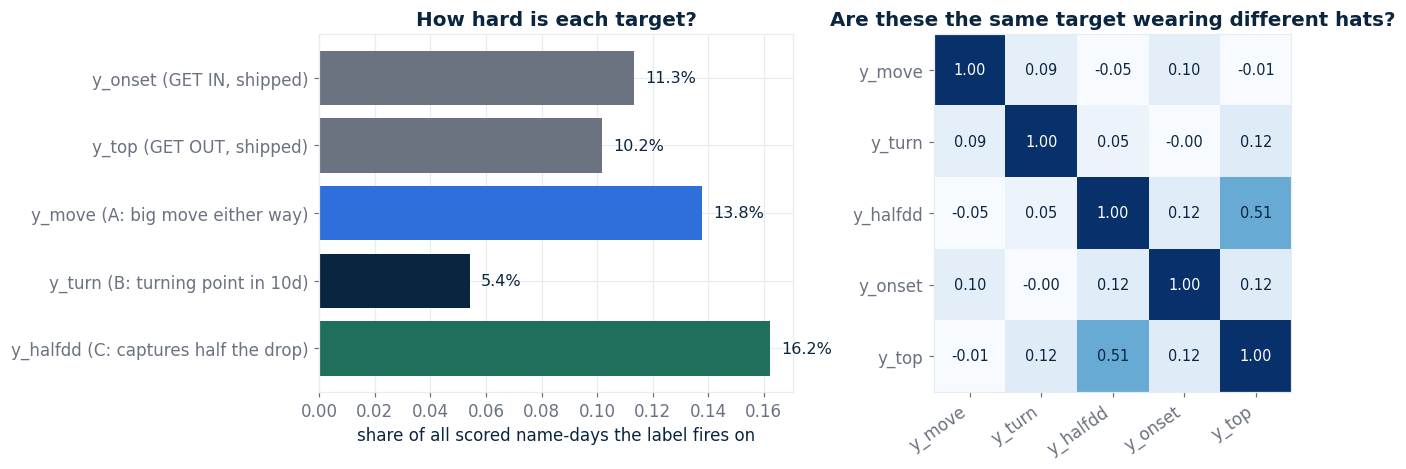

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax = axes[0]
ax.barh(BASE["label"], BASE["base_rate"], color=[GREY, GREY, BLUE, NAVY,
                                                 GREEN])
for i, v in enumerate(BASE["base_rate"]):
    ax.text(v + 0.004, i, f"{v:.1%}", va="center", fontsize=10.5)
ax.set_xlabel("share of all scored name-days the label fires on")
ax.set_title("How hard is each target?")
ax.invert_yaxis()

ax = axes[1]
ov = pd.DataFrame({k: D[k] for k in ("y_move", "y_turn", "y_halfdd",
                                     "y_onset", "y_top")}).corr()
im = ax.imshow(ov.values, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(ov)), ov.columns, rotation=35, ha="right")
ax.set_yticks(range(len(ov)), ov.columns)
for i in range(len(ov)):
    for j in range(len(ov)):
        ax.text(j, i, f"{ov.values[i, j]:.2f}", ha="center", va="center",
                fontsize=9.5,
                color="white" if ov.values[i, j] > 0.55 else NAVY)
ax.grid(False)
ax.set_title("Are these the same target wearing different hats?")
fig.tight_layout()
plt.show()

# 2 — Baseline: how the shipped features score on the new targets

Before searching for anything better, measure what we already have.
The walk-forward below is written **in this notebook** rather than
imported, so nothing in the pipeline is touched and the fold logic is
visible on the page: for each year Y, fit on every year `< Y`, score
Y blind, and never look at Y while fitting.

In [10]:
from sklearn.metrics import average_precision_score, roc_auc_score  # noqa: E402


def walk_forward(df: pd.DataFrame, feats: list, label: str,
                 fit_maker, min_train: int = 400) -> pd.DataFrame:
    """Fit on years < Y, score Y. Returns one row per scored name-day."""
    out = []
    years = sorted(df["year"].unique())
    for y in years:
        tr = df[df["year"] < y]
        te = df[df["year"] == y]
        if len(tr) < min_train or not len(te) or tr[label].sum() < 12:
            continue
        try:
            s = fit_maker(label)(tr, te, feats)
        except Exception as e:                       # noqa: BLE001
            print(f"   [{label} {y}] fit failed: {e}")
            continue
        out.append(te.assign(score=np.asarray(s)))
    return pd.concat(out) if out else pd.DataFrame()


def score_report(scored: pd.DataFrame, label: str) -> dict:
    if not len(scored) or scored[label].nunique() < 2:
        return {"n": len(scored), "AP": np.nan, "AUROC": np.nan,
                "base": np.nan, "AP_lift": np.nan}
    y = scored[label].to_numpy()
    s = scored["score"].to_numpy()
    base = float(y.mean())
    ap = float(average_precision_score(y, s))
    return {"n": len(scored), "AP": ap,
            "AUROC": float(roc_auc_score(y, s)), "base": base,
            "AP_lift": ap / base if base else np.nan}


LABELS = [("y_move", "A · big move either way"),
          ("y_turn", "B · turning point in 10d"),
          ("y_halfdd", "C · captures half the drop"),
          ("y_onset", "GET IN (shipped grading)"),
          ("y_top", "GET OUT (shipped grading)")]

t = time.time()
BASELINE = {}
for lb, nice in LABELS:
    sc = walk_forward(D, CROWD, lb, mld.make_ens_fit)
    BASELINE[lb] = score_report(sc, lb)
    BASELINE[lb]["label"] = nice
    print(f"  {nice:<32} AP {BASELINE[lb]['AP']:.4f}  "
          f"lift {BASELINE[lb]['AP_lift']:.2f}x  "
          f"AUROC {BASELINE[lb]['AUROC']:.4f}")
print(f"({time.time() - t:.0f}s)")
RESULTS["sections"]["baseline_crowd"] = BASELINE

  A · big move either way          AP 0.1383  lift 1.00x  AUROC 0.4918


  B · turning point in 10d         AP 0.0593  lift 1.06x  AUROC 0.5176


  C · captures half the drop       AP 0.1998  lift 1.20x  AUROC 0.5434


  GET IN (shipped grading)         AP 0.1424  lift 1.25x  AUROC 0.5578


  GET OUT (shipped grading)        AP 0.1271  lift 1.21x  AUROC 0.5496
(11s)


**The shipped crowd bank, scored on the new targets.** This is the
number every later section has to beat. If a new label shows a big
lift here it means the crowd features already carry that signal and we
simply were not asking for it — which would be the cheapest possible
win.

# 3 — The search

Scope, per the desk: everything except the text-free boundary and
walk-forward. Three axes, run for every label:

* **feature bank** — crowd-only, crowd+price, and crowd+price plus the
  candidate additions defined below;
* **model family** — logistic regression, monotone GBM, and the
  rank-average ensemble that ships today;
* **target** — the five labels above.

Nothing is adopted in this section. It produces a table.

## 3.1 Candidate new features

Four additions, each with a reason to exist rather than a hope:

* `att_vol_21` — how *unstable* attention has been, not how high. A
  crowd arguing with itself looks different from a crowd agreeing, and
  neither the level nor the trend measures capture that.
* `bull_dispersion` — the spread of daily mood over 21 days. High
  dispersion is disagreement, and disagreement is what precedes a
  reversal in the folklore this project is testing.
* `att_x_mood` — attention × mood, the interaction. Loud-and-bullish
  and loud-and-bearish are different states; two additive terms cannot
  say that.
* `breadth_chg` — change in how many sources carry the name. A move
  spreading across forums is different from one forum shouting.

All four are computed **per name from its own history** and none of
them touches price.

In [11]:
def add_candidates(df: pd.DataFrame) -> pd.DataFrame:
    d = df.sort_values(["name", "date"]).copy()
    g = d.groupby("name", sort=False)
    d["att_vol_21"] = g["hype_raw"].transform(
        lambda s: s.rolling(21, min_periods=8).std())
    d["bull_dispersion"] = g["bull_level"].transform(
        lambda s: s.rolling(21, min_periods=8).std())
    d["att_x_mood"] = d["e1"] * d["bull_level"]
    if "source_breadth" in d:
        d["breadth_chg"] = g["source_breadth"].transform(
            lambda s: s - s.rolling(21, min_periods=8).mean())
    else:
        d["breadth_chg"] = 0.0
    for c in ("att_vol_21", "bull_dispersion", "att_x_mood",
              "breadth_chg"):
        d[c] = d[c].fillna(0.0)
    return d.loc[df.index]


D = add_candidates(D)
NEW_FEATS = ["att_vol_21", "bull_dispersion", "att_x_mood", "breadth_chg"]
BANKS = {
    "crowd only (shipped)": CROWD,
    "crowd + price (shipped desk)": mld.DESK_ML_BANK,
    "crowd + new": CROWD + NEW_FEATS,
    "crowd + price + new": mld.DESK_ML_BANK + NEW_FEATS,
}
FAMILIES = {"logit": mld.make_logit_fit, "monotone GBM": mld.make_gbm_fit,
            "ensemble (shipped)": mld.make_ens_fit}
print(f"{len(BANKS)} banks x {len(FAMILIES)} families x {len(LABELS)} "
      f"labels = {len(BANKS) * len(FAMILIES) * len(LABELS)} walk-forwards")

4 banks x 3 families x 5 labels = 60 walk-forwards


In [12]:
t = time.time()
rows = []
for lb, nice in LABELS:
    for bname, feats in BANKS.items():
        for fname, maker in FAMILIES.items():
            sc = walk_forward(D, feats, lb, maker)
            r = score_report(sc, lb)
            r.update({"label": nice, "label_col": lb, "bank": bname,
                      "family": fname})
            rows.append(r)
    print(f"  {nice} done ({time.time() - t:.0f}s)")
SEARCH = pd.DataFrame(rows)
RESULTS["sections"]["search"] = SEARCH.to_dict("records")
print(f"\ntournament finished in {time.time() - t:.0f}s")

  A · big move either way done (16s)


  B · turning point in 10d done (39s)


  C · captures half the drop done (61s)


  GET IN (shipped grading) done (82s)


  GET OUT (shipped grading) done (105s)

tournament finished in 105s


In [13]:
piv = SEARCH.pivot_table(index=["label", "bank"], columns="family",
                         values="AP_lift").round(2)
print("AP LIFT over each label's own base rate (higher is better)\n")
print(piv.to_string())

AP LIFT over each label's own base rate (higher is better)

family                                                   ensemble (shipped)  logit  monotone GBM
label                      bank                                                                 
A · big move either way    crowd + new                                 1.04   0.95          1.06
                           crowd + price (shipped desk)                0.97   0.91          1.03
                           crowd + price + new                         1.02   0.94          1.04
                           crowd only (shipped)                        1.00   0.91          1.00
B · turning point in 10d   crowd + new                                 1.34   1.31          1.21
                           crowd + price (shipped desk)                1.37   1.27          1.19
                           crowd + price + new                         1.44   1.38          1.29
                           crowd only (shipped)                    

In [14]:
best = (SEARCH.sort_values("AP_lift", ascending=False)
        .groupby("label_col").head(1)
        .set_index("label_col"))
shipped = SEARCH[(SEARCH["bank"] == "crowd only (shipped)")
                 & (SEARCH["family"] == "ensemble (shipped)")
                 ].set_index("label_col")
cmp = pd.DataFrame({
    "shipped_lift": shipped["AP_lift"].round(2),
    "best_lift": best["AP_lift"].round(2),
    "best_bank": best["bank"], "best_family": best["family"],
    "gain": (best["AP_lift"] - shipped["AP_lift"]).round(2),
})
print(cmp.to_string())
RESULTS["sections"]["best_vs_shipped"] = cmp.reset_index().to_dict("records")

           shipped_lift  best_lift                     best_bank         best_family  gain
label_col                                                                                 
y_halfdd           1.20       2.02  crowd + price (shipped desk)  ensemble (shipped)  0.82
y_move             1.00       1.06                   crowd + new        monotone GBM  0.06
y_onset            1.25       2.59           crowd + price + new               logit  1.34
y_top              1.21       2.49  crowd + price (shipped desk)  ensemble (shipped)  1.29
y_turn             1.06       1.44           crowd + price + new  ensemble (shipped)  0.38


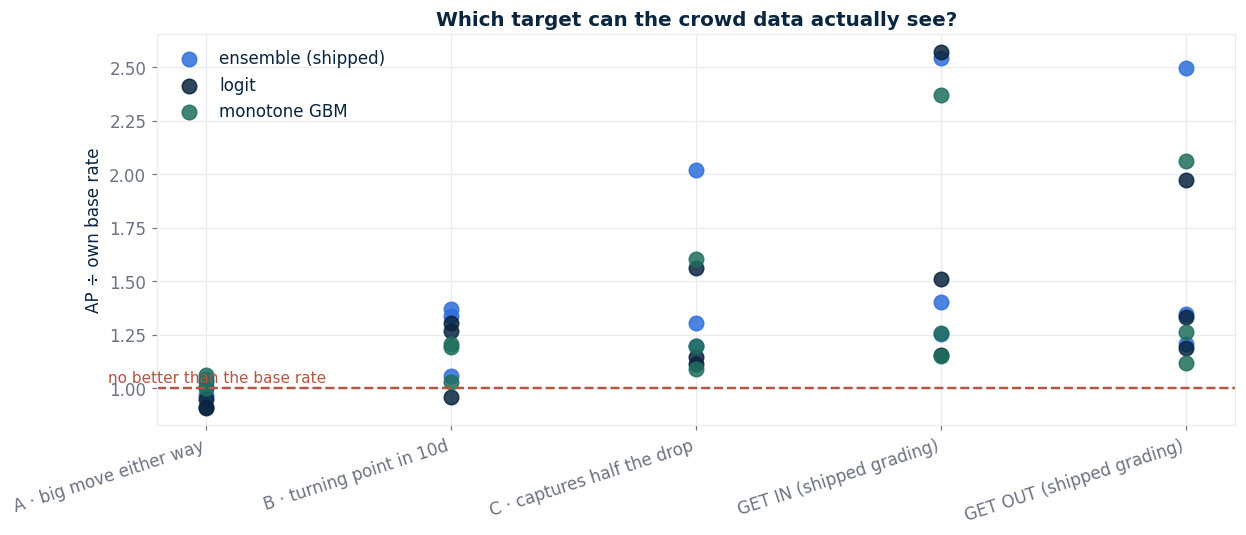

In [15]:
fig, ax = plt.subplots(figsize=(11.5, 5.0))
_p = SEARCH[SEARCH["bank"] != "crowd + price + new"]
for i, (fam, g) in enumerate(_p.groupby("family")):
    ax.scatter(g["label"], g["AP_lift"], s=90, alpha=0.85,
               color=[BLUE, NAVY, GREEN][i % 3], label=fam)
ax.axhline(1.0, color=RED, lw=1.6, ls="--")
ax.text(-0.4, 1.03, "no better than the base rate", color=RED,
        fontsize=10)
ax.set_ylabel("AP ÷ own base rate")
ax.set_title("Which target can the crowd data actually see?")
ax.legend(frameon=False)
plt.xticks(rotation=18, ha="right")
fig.tight_layout()
plt.show()

## 3.2 How much of this is the crowd, and how much is just price?

**The most important table in this notebook.** Every headline gain
above needs splitting, because two very different things are on offer:

* adding **four new crowd features** — price-free, so adoptable inside
  the rule the desk deliberately keeps;
* adding **price** to detectors that currently never see it — which
  would raise the numbers a lot and change what the project is
  *claiming*, from "the crowd predicts this" to "partly, price
  predicts price".

The second is not free even though it is bigger.

In [16]:
BYBANK = (SEARCH.groupby(["label", "bank"])["AP_lift"].max()
          .unstack()[["crowd only (shipped)", "crowd + new",
                      "crowd + price (shipped desk)",
                      "crowd + price + new"]].round(2))
SPLIT = pd.DataFrame({
    "shipped (crowd only)": BYBANK["crowd only (shipped)"],
    "+ new crowd features": (BYBANK["crowd + new"]
                             - BYBANK["crowd only (shipped)"]).round(2),
    "+ price (rule change)": (BYBANK["crowd + price (shipped desk)"]
                              - BYBANK["crowd only (shipped)"]).round(2),
    "best available": BYBANK.max(axis=1),
})
print(SPLIT.to_string())
RESULTS["sections"]["gain_split"] = SPLIT.reset_index().to_dict("records")

                            shipped (crowd only)  + new crowd features  + price (rule change)  best available
label                                                                                                        
A · big move either way                     1.00                  0.06                   0.03            1.06
B · turning point in 10d                    1.06                  0.28                   0.31            1.44
C · captures half the drop                  1.20                  0.10                   0.82            2.02
GET IN (shipped grading)                    1.25                  0.26                   1.32            2.59
GET OUT (shipped grading)                   1.21                  0.14                   1.28            2.49


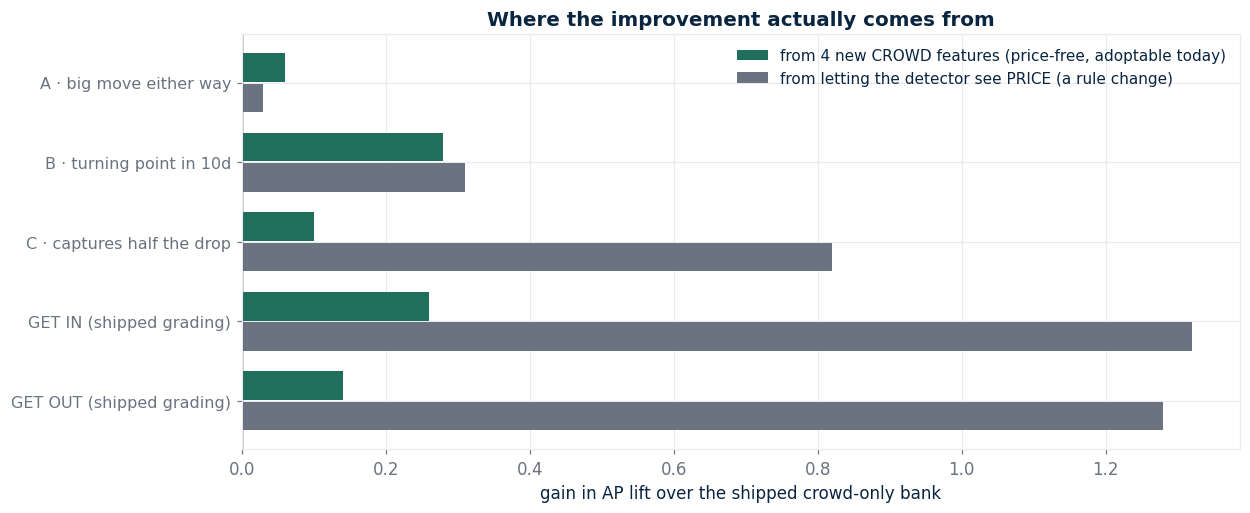

In [17]:
fig, ax = plt.subplots(figsize=(11.5, 4.8))
_y = np.arange(len(SPLIT))
ax.barh(_y - 0.19, SPLIT["+ new crowd features"], 0.36, color=GREEN,
        label="from 4 new CROWD features (price-free, adoptable today)")
ax.barh(_y + 0.19, SPLIT["+ price (rule change)"], 0.36, color=GREY,
        label="from letting the detector see PRICE (a rule change)")
ax.axvline(0, color=NAVY, lw=1.6)
ax.set_yticks(_y, SPLIT.index, fontsize=10.5)
ax.set_xlabel("gain in AP lift over the shipped crowd-only bank")
ax.set_title("Where the improvement actually comes from")
ax.legend(frameon=False, fontsize=10)
ax.invert_yaxis()
fig.tight_layout()
plt.show()

### A caveat that applies to every score in this notebook

The forward windows **overlap**: day *t* and day *t+1* share 20 of
their 21 forward days, so consecutive rows are nearly the same
observation. The row counts above therefore overstate the independent
sample by roughly the horizon — the effective *n* is closer to
`n / 21` than to `n`. Treat differences smaller than about 0.15 in
lift as noise, and read the year-by-year consistency below as the real
evidence rather than the pooled number.

In [18]:
CONSIST = []
for lb, nice in LABELS:
    row = SEARCH[(SEARCH["label_col"] == lb)].nlargest(1, "AP_lift")
    if not len(row):
        continue
    feats = BANKS[row["bank"].iloc[0]]
    maker = FAMILIES[row["family"].iloc[0]]
    sc = walk_forward(D, feats, lb, maker)
    for y, g in sc.groupby("year"):
        r = score_report(g, lb)
        if r["AP_lift"] == r["AP_lift"]:
            CONSIST.append({"label": nice, "year": int(y),
                            "AP_lift": round(r["AP_lift"], 2),
                            "n": r["n"]})
CONSIST = pd.DataFrame(CONSIST)
if len(CONSIST):
    tab = CONSIST.pivot_table(index="label", columns="year",
                              values="AP_lift")
    print("AP lift, YEAR BY YEAR (best config per label)\n")
    print(tab.round(2).to_string())
    print("\nyears where the best config beat its base rate:")
    print(((tab > 1.0).sum(axis=1).astype(str) + " / "
           + tab.notna().sum(axis=1).astype(str)).to_string())
RESULTS["sections"]["year_consistency"] = CONSIST.to_dict("records")

AP lift, YEAR BY YEAR (best config per label)

year                        2018  2019  2020  2021  2022  2023  2024  2025  2026
label                                                                           
A · big move either way     1.08  1.07  0.98  1.30  1.02  1.04  1.48  1.69  1.17
B · turning point in 10d    1.04  1.69  1.32  2.09  1.05  1.28   NaN   NaN  1.31
C · captures half the drop  2.06  1.55  1.30  2.19  2.60  1.83  5.06  0.80  2.13
GET IN (shipped grading)    2.85  2.22  1.89  4.64  1.98  5.04  2.58   NaN  3.08
GET OUT (shipped grading)   1.94  1.89  1.39  3.38  2.82  2.38  7.10   NaN  2.19

years where the best config beat its base rate:
label
A · big move either way       8 / 9
B · turning point in 10d      7 / 7
C · captures half the drop    8 / 9
GET IN (shipped grading)      8 / 8
GET OUT (shipped grading)     8 / 8


# 4 — The inflection head, end to end

Whichever label wins §3, a score is not a signal. This section turns
the best inflection model into **flags** and asks the only question
that matters: *after a flag, does the price actually move?*

The trigger reuses the shape the desk adopted on 2026-08-09 —
crossing, deep re-arm, spacing — because the reason for it (a level
trigger re-fires all the way up a rally) applies here unchanged.

In [19]:
INFL_LABEL = cmp["best_lift"].drop(index=["y_onset", "y_top"],
                                   errors="ignore").idxmax()
INFL_ROW = best.loc[INFL_LABEL]
INFL_FEATS = BANKS[INFL_ROW["bank"]]
INFL_FIT = FAMILIES[INFL_ROW["family"]]
print(f"inflection head: {INFL_LABEL} · {INFL_ROW['bank']} · "
      f"{INFL_ROW['family']} (lift {INFL_ROW['AP_lift']:.2f}x)")
SCORED = walk_forward(D, INFL_FEATS, INFL_LABEL, INFL_FIT)
print(f"{len(SCORED):,} out-of-sample scored days")

inflection head: y_halfdd · crowd + price (shipped desk) · ensemble (shipped) (lift 2.02x)


37,049 out-of-sample scored days


In [20]:
def flags_from(scored: pd.DataFrame, q: float, rearm_q: float = 0.55,
               spacing: int = 21) -> pd.DataFrame:
    """Upward crossings of a percentile cut, re-armed below a lower one,
    at most one flag per name per `spacing` days."""
    thr = scored["score"].quantile(q)
    rearm = scored["score"].quantile(rearm_q)
    keep = []
    for nm, g in scored.sort_values(["name", "date"]).groupby("name"):
        armed, last = True, None
        for r in g.itertuples():
            if r.score < rearm:
                armed = True
            if armed and r.score >= thr and (
                    last is None or (r.date - last).days >= spacing):
                keep.append(r.Index)
                armed, last = False, r.date
    return scored.loc[keep]


def flag_outcome(flags: pd.DataFrame) -> dict:
    """What actually happens in the 21 days after a flag."""
    ex, hit, adir = [], [], []
    for r in flags.itertuples():
        m = MOVE.get(r.name)
        if m is None or r.date not in m.index:
            continue
        ex.append(float(m.loc[r.date, "excess"]))
        hit.append(int(m.loc[r.date, "y_move"]))
        adir.append(int(m.loc[r.date, "move_dir"]))
    if not ex:
        return {}
    ex = np.asarray(ex)
    return {"flags": len(ex), "hit_rate": float(np.mean(hit)),
            "mean_abs_excess": float(np.mean(np.abs(ex))),
            "median_abs_excess": float(np.median(np.abs(ex))),
            "share_up": float(np.mean(np.asarray(adir) > 0)),
            "mean_excess": float(np.mean(ex))}


base_hit = float(D.loc[D.index.isin(SCORED.index), "y_move"].mean())
base_abs = float(np.mean([abs(v) for nm in MOVE
                          for v in MOVE[nm]["excess"].to_numpy()[-2000:]]))
rows = []
for q in (0.90, 0.95, 0.97, 0.99):
    f = flags_from(SCORED, q)
    o = flag_outcome(f)
    if o:
        o["cut"] = f"top {100 * (1 - q):.0f}%"
        o["lift_vs_base"] = o["hit_rate"] / base_hit if base_hit else np.nan
        rows.append(o)
FLAGS = pd.DataFrame(rows)[["cut", "flags", "hit_rate", "lift_vs_base",
                            "median_abs_excess", "mean_abs_excess",
                            "share_up"]]
print(f"base rate of a big move on a random scored day: {base_hit:.3f}\n")
print(FLAGS.round(3).to_string(index=False))
RESULTS["sections"]["flag_outcomes"] = FLAGS.to_dict("records")

base rate of a big move on a random scored day: 0.138

    cut  flags  hit_rate  lift_vs_base  median_abs_excess  mean_abs_excess  share_up
top 10%    330     0.164         1.188              0.041            0.077     0.585
 top 5%    201     0.144         1.047              0.046            0.097     0.587
 top 3%    132     0.144         1.045              0.046            0.114     0.591
 top 1%     49     0.184         1.333              0.086            0.479     0.490


**How to read this table.** `hit_rate` is the share of flags followed
by a genuinely large move; `lift_vs_base` compares that with flagging
a random day. A lift near 1.0 means the flag is decoration. `share_up`
says whether the flag is direction-neutral in practice — if it sits
near 0.5 the honest label really is "something is about to happen",
and the *direction* has to come from somewhere else, which is what §5
is for.

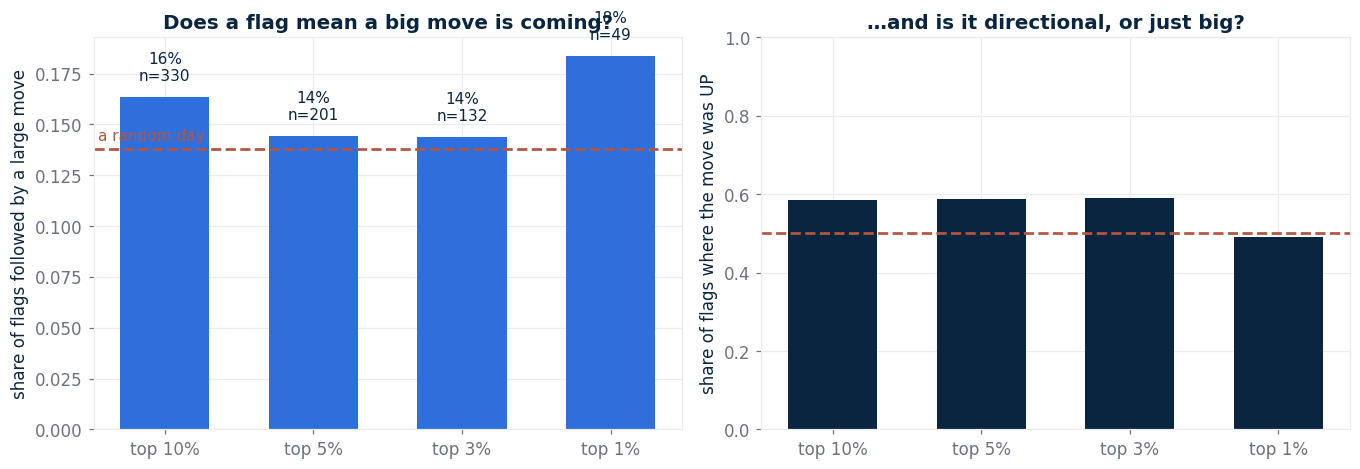

In [21]:
if len(FLAGS):
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
    ax = axes[0]
    ax.bar(FLAGS["cut"], FLAGS["hit_rate"], color=BLUE, width=0.6)
    ax.axhline(base_hit, color=RED, lw=1.8, ls="--")
    ax.text(-0.45, base_hit * 1.03, "a random day", color=RED, fontsize=10)
    for i, (h, n) in enumerate(zip(FLAGS["hit_rate"], FLAGS["flags"])):
        ax.text(i, h + 0.008, f"{h:.0%}\nn={n}", ha="center", fontsize=10)
    ax.set_title("Does a flag mean a big move is coming?")
    ax.set_ylabel("share of flags followed by a large move")
    ax = axes[1]
    ax.bar(FLAGS["cut"], FLAGS["share_up"], color=NAVY, width=0.6)
    ax.axhline(0.5, color=RED, lw=1.8, ls="--")
    ax.set_ylim(0, 1)
    ax.set_title("…and is it directional, or just big?")
    ax.set_ylabel("share of flags where the move was UP")
    fig.tight_layout()
    plt.show()

## 4.1 The direction hint

If §4 shows the flag is close to direction-neutral, a flag on its own
cannot be traded. The cheap fix is a **second, separate model** whose
only job is to guess the sign *given that a move is coming* — trained
only on the days where a large move did occur, which is a far more
balanced problem than predicting the move itself.

In [22]:
MOVE_DAYS = D[D["y_move"] == 1].copy()
MOVE_DAYS["y_up"] = (_attach(MOVE, "move_dir").reindex(MOVE_DAYS.index) > 0
                     ).astype(int)
print(f"{len(MOVE_DAYS):,} large-move days · "
      f"{MOVE_DAYS['y_up'].mean():.1%} of them were UP")
dir_sc = walk_forward(MOVE_DAYS, INFL_FEATS, "y_up", mld.make_ens_fit)
DIRREP = score_report(dir_sc, "y_up")
print(f"direction model: AUROC {DIRREP['AUROC']:.4f} "
      f"(0.50 = a coin flip), n={DIRREP['n']:,}")
RESULTS["sections"]["direction_model"] = DIRREP

5,329 large-move days · 68.5% of them were UP


direction model: AUROC 0.5225 (0.50 = a coin flip), n=4,465


# 4.2 — What the adopted changes actually look like

Desk request: *"show me what some plots would look like with the new
changes like the adopt stuff (all). also Label B too."*

Five names, drawn with **everything this notebook recommends adopting
at once**:

* the **four new crowd features** in the bank (still price-free);
* **GET OUT regraded** on capture-half-the-drawdown rather than
  proximity to the peak;
* **GET IN** on the existing grading, which the new features also
  improve;
* **label B turning points** as a third, separate marker.

Every mark is walk-forward: the model that placed it was fitted only
on years before the year the mark sits in. The triggers reuse the
shipped shape (crossing, deep re-arm, spacing) because the reason for
it — a level trigger re-fires all the way up a rally — is unchanged.

In [23]:
SHOW = [("meme_stocks", "ARKK", "Meme stocks"),
        ("gold_metals", "GLD", "Gold"),
        ("semiconductors", "SMH", "Semiconductors"),
        ("ai", "IYW", "AI / broad tech"),
        ("europe_defense", "EUAD", "Europe defence")]
ADOPTED = CROWD + NEW_FEATS          # price-free, as recommended

HEADS = {}
for _lb, _cut, _space, _nice in (("y_onset", 0.97, 63, "GET IN"),
                                 ("y_halfdd", 0.97, 63, "GET OUT"),
                                 ("y_turn", 0.97, 21, "TURN")):
    _sc = walk_forward(D, ADOPTED, _lb, mld.make_ens_fit)
    HEADS[_nice] = {"scored": _sc,
                    "flags": flags_from(_sc, _cut, spacing=_space)
                    if len(_sc) else pd.DataFrame(),
                    "label": _lb}
    print(f"{_nice:<8} {len(HEADS[_nice]['flags']):>4} flags "
          f"from {len(_sc):,} scored days")

GET IN    133 flags from 37,049 scored days


GET OUT   148 flags from 37,049 scored days


TURN      180 flags from 37,049 scored days


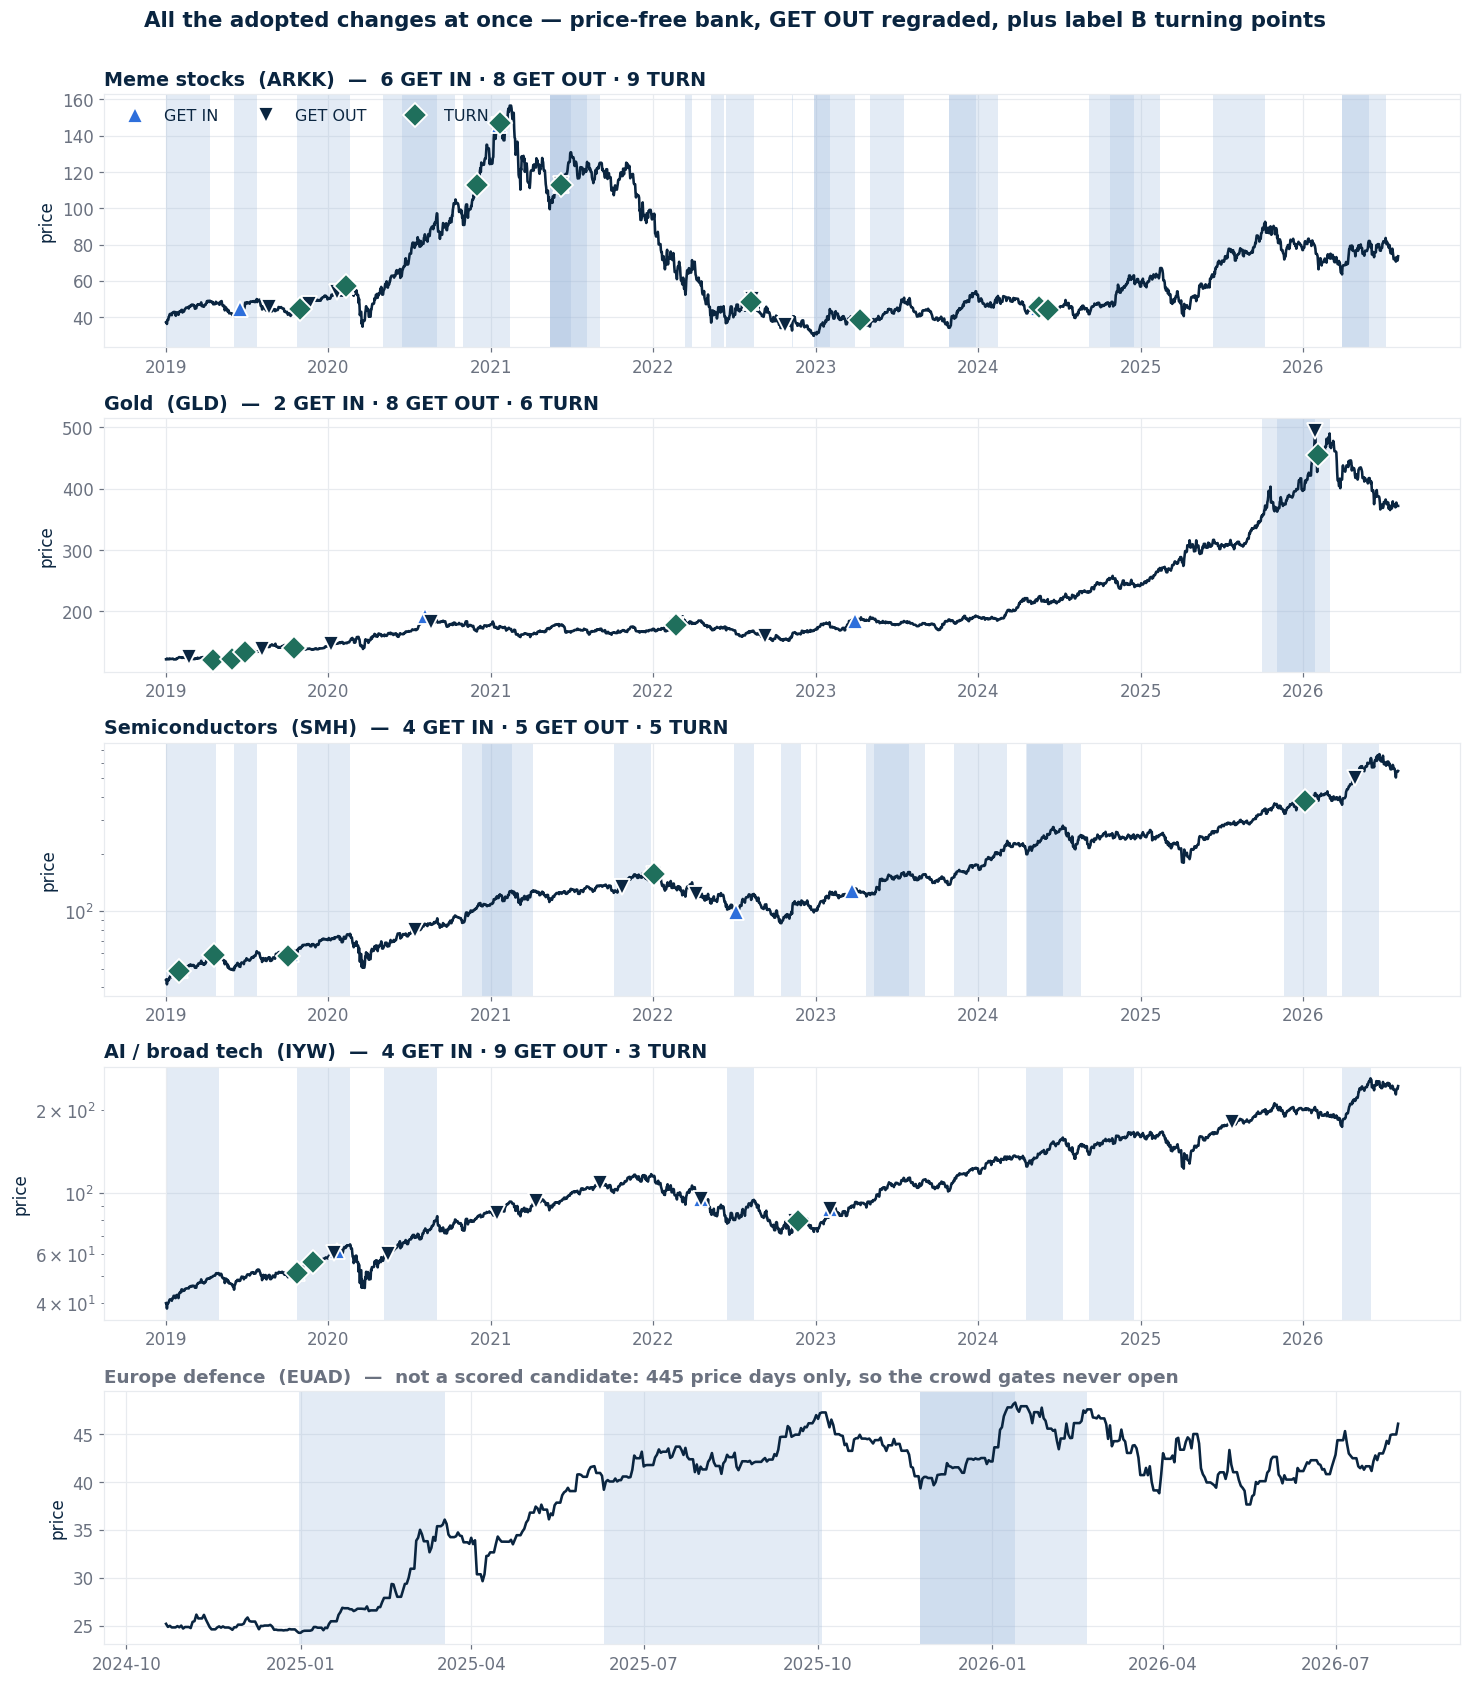

In [24]:
MARK = {"GET IN": (BLUE, "^"), "GET OUT": (NAVY, "v"),
        "TURN": (GREEN, "D")}
fig, axes = plt.subplots(len(SHOW), 1, figsize=(13.5, 3.05 * len(SHOW)),
                         sharex=False)
for ax, (nm, sym, nice) in zip(np.atleast_1d(axes), SHOW):
    px = pxmap.get(sym)
    if px is None or not len(px.dropna()):
        ax.text(0.5, 0.5, f"{nice} ({sym}) — no price series",
                ha="center", va="center", transform=ax.transAxes,
                color=GREY)
        ax.set_yticks([])
        continue
    px = px.dropna().loc["2019-01-01":]
    ax.plot(px.index, px.values, color=NAVY, lw=1.7, zorder=2)
    if len(px) and px.max() / max(px.min(), 1e-9) > 6:
        ax.set_yscale("log")
    for r in episodes[episodes["name"] == nm].itertuples():
        if r.peak >= px.index.min() and r.trough <= px.index.max():
            ax.axvspan(max(r.trough, px.index.min()),
                       min(r.peak, px.index.max()), color=SKY,
                       alpha=0.28, lw=0, zorder=1)
    counts = {}
    for head, spec in HEADS.items():
        f = spec["flags"]
        f = f[f["name"] == nm] if len(f) else f
        d = [x for x in (f["date"] if len(f) else [])
             if px.index.min() <= x <= px.index.max()]
        counts[head] = len(d)
        col, mk = MARK[head]
        ax.plot(d, [px.asof(x) for x in d], mk, color=col, ms=11,
                mec="white", mew=1.2, zorder=5, label=head)
    if nm not in set(D["name"]):
        ax.set_title(f"{nice}  ({sym})  —  not a scored candidate: "
                     f"{len(prices[prices['symbol'] == sym]):,} price days "
                     f"only, so the crowd gates never open",
                     loc="left", fontsize=12, color=GREY)
    else:
        ax.set_title(f"{nice}  ({sym})  —  "
                     + " · ".join(f"{v} {k}" for k, v in counts.items()),
                     loc="left", fontsize=12.5)
        if ax is np.atleast_1d(axes)[0]:
            ax.legend(frameon=False, ncol=3, fontsize=10.5,
                      loc="upper left")
    ax.set_ylabel("price")
    ax.tick_params(axis="x", rotation=0)
fig.suptitle("All the adopted changes at once — price-free bank, GET OUT "
             "regraded, plus label B turning points", fontsize=14,
             fontweight="bold", y=1.002)
fig.tight_layout()
plt.show()

## 4.2b Did the changes move the marks, or just relabel them?

A picture can look different for cosmetic reasons. This compares the
SHIPPED crowd-only bank against the ADOPTED one on the same five
names, same cut, same trigger — so any difference is the four new
features and the regrade, nothing else.

In [25]:
def _head_flags(bank, label, cut=0.97, spacing=63):
    sc = walk_forward(D, bank, label, mld.make_ens_fit)
    return flags_from(sc, cut, spacing=spacing) if len(sc) else pd.DataFrame()


rows = []
for label, spacing, nice in (("y_onset", 63, "GET IN"),
                             ("y_halfdd", 63, "GET OUT"),
                             ("y_turn", 21, "TURN")):
    for bank_name, bank in (("shipped crowd-only", CROWD),
                            ("adopted (crowd + new)", ADOPTED)):
        f = _head_flags(bank, label, spacing=spacing)
        if not len(f):
            continue
        sub = f[f["name"].isin([n for n, _, _ in SHOW])]
        hit = float(sub[label].mean()) if len(sub) else np.nan
        rows.append({"head": nice, "bank": bank_name,
                     "flags (all names)": len(f),
                     "flags (these 5)": len(sub),
                     "hit rate (these 5)": round(hit, 3)
                     if hit == hit else np.nan,
                     "hit rate (all)": round(float(f[label].mean()), 3)})
CMP5 = pd.DataFrame(rows)
print(CMP5.to_string(index=False))
RESULTS["sections"]["five_names_compare"] = CMP5.to_dict("records")

   head                  bank  flags (all names)  flags (these 5)  hit rate (these 5)  hit rate (all)
 GET IN    shipped crowd-only                244               38               0.263           0.205
 GET IN adopted (crowd + new)                133               16               0.312           0.218
GET OUT    shipped crowd-only                150               28               0.321           0.213
GET OUT adopted (crowd + new)                148               34               0.265           0.230
   TURN    shipped crowd-only                278               50               0.080           0.079
   TURN adopted (crowd + new)                180               25               0.040           0.061


**Reading it.** `hit rate` here is the share of flags where the label
was in fact true on that day — for GET OUT that means the call went on
to capture half the drawdown, for TURN that a real reversal landed
within ten days. It is the single most direct answer to *"is the flag
telling the truth?"*, and it is the number to watch when the backfill
lands.

# 4.3 — The half-drawdown regrade, REJECTED

Desk, 2026-08-12, on reading §3: *"i think the previous get out was
better — ie. without the half drawdown stuff"*. They were right, and
the mistake that hid it is worth recording as carefully as the result.

**The error.** §3 reports label C going 1.20 → 2.02 and `y_top` going
1.21 → 2.49. Those are each a label's gain against ITS OWN crowd-only
baseline, and reading the first as evidence that C beats the existing
grading is simply wrong — `y_top` is higher at every configuration.
C's larger raw AP (0.200 vs 0.127) is almost entirely its larger base
rate (16.7% vs 10.5%): an easier target, not a better-served one, and
lift already controls for that. The two were effectively tied from the
first table.

**The decisive test** is not AP at all. Fire flags from each head with
the same bank and the same trigger, then judge BOTH on the SAME
yardsticks — including C's own objective.

In [26]:
D["ex21"] = _attach(MOVE, "excess")
GRADE = []
for _label, _nice in (("y_top", "OLD grading (near the peak)"),
                      ("y_halfdd", "NEW grading (half the drawdown)")):
    _sc = walk_forward(D, CROWD, _label, mld.make_ens_fit)
    _f = flags_from(_sc, 0.97, spacing=63)
    _sub = D.loc[_f.index]
    GRADE.append({
        "head": _nice, "flags": len(_f),
        "own-label hit": round(float(_f[_label].mean()), 3),
        "captured >=50% of dd": round(
            float((_sub["dd_captured"] >= 0.5).mean()), 3),
        "median dd captured": round(
            float(_sub["dd_captured"].median()), 3),
        "fwd 21d excess %": round(100 * float(_sub["ex21"].mean()), 2),
        "share fwd < 0": round(float((_sub["ex21"] < 0).mean()), 3)})
GRADE = pd.DataFrame(GRADE)
print(GRADE.to_string(index=False))
print(f"\nreference — a RANDOM scored day: median dd captured "
      f"{D['dd_captured'].median():.3f} · fwd 21d excess "
      f"{100 * D['ex21'].mean():.2f}% · share negative "
      f"{(D['ex21'] < 0).mean():.3f}")
RESULTS["sections"]["grading_arbitration"] = GRADE.to_dict("records")

                           head  flags  own-label hit  captured >=50% of dd  median dd captured  fwd 21d excess %  share fwd < 0
    OLD grading (near the peak)    168          0.161                 0.196               0.442              2.40          0.375
NEW grading (half the drawdown)    150          0.213                 0.213               0.498              4.95          0.307

reference — a RANDOM scored day: median dd captured 0.394 · fwd 21d excess 1.54% · share negative 0.443


**The arbitration is MIXED, and the mix is the finding.** On its own
objective the half-drawdown head does slightly better — it captures
at least half the fall a little more often, and its median call
captures more of the drawdown. On the yardstick that decides whether
a GET OUT was any use, it is clearly worse: names it flags go on to
OUTPERFORM the market by roughly twice as much over the following
month, and fewer of them fall at all.

Forward return decides it. A GET OUT exists to get you out before a
fall; a call that captures a large share of a drawdown while the name
still beats the market has captured a share of nothing much. The
capture column is also the less trustworthy of the two — an earlier
one-off run of this same comparison, over a slightly different row
filter, put the capture ordering the other way round while the
forward-return ordering held. A metric that flips on a filter change
at ~160 flags is telling you it is noisy; the one that does not flip
is the one to act on.

**Why it fails, mechanically.** "Captures half the eventual drawdown"
marks as positive almost any day from the trough onward that happens
to precede a fall — including days early in the run-up, months before
the top. A model trained on it learns to flag EARLY IN THE EPISODE,
and the forward-return column is that behaviour showing up: it is
flagging names that then keep climbing. The peak-proximity grading is
cruder, but it forces the model toward the end of the run, which is
where a GET OUT has to live. **Timing-agnostic turned out to mean
timing-blind.**

DECISION: the half-drawdown regrade is **rejected**. The existing
GET OUT grading stays.

# 4.4 — The new features, re-tested on the grading we are keeping

§4.2's flag table graded GET OUT on the label §4.3 just rejected, so
its GET OUT numbers cannot support an adoption. Re-run here against
`y_top`, which is what actually ships. Price-free bank throughout.

In [27]:
KEEP = []
for _label, _nice in (("y_onset", "GET IN"),
                      ("y_top", "GET OUT (existing grading)")):
    for _bn, _bank in (("shipped crowd-only", CROWD),
                       ("+ 4 new features", CROWD + NEW_FEATS)):
        _sc = walk_forward(D, _bank, _label, mld.make_ens_fit)
        _f = flags_from(_sc, 0.97, spacing=63)
        _sub = D.loc[_f.index]
        KEEP.append({"head": _nice, "bank": _bn, "flags": len(_f),
                     "hit rate": round(float(_f[_label].mean()), 3),
                     "fwd 21d excess %": round(
                         100 * float(_sub["ex21"].mean()), 2),
                     "share fwd < 0": round(
                         float((_sub["ex21"] < 0).mean()), 3)})
KEEP = pd.DataFrame(KEEP)
print(KEEP.to_string(index=False))
RESULTS["sections"]["features_on_kept_grading"] = KEEP.to_dict("records")

                      head               bank  flags  hit rate  fwd 21d excess %  share fwd < 0
                    GET IN shipped crowd-only    244     0.205              4.02          0.385
                    GET IN   + 4 new features    133     0.218              4.63          0.398
GET OUT (existing grading) shipped crowd-only    168     0.161              2.40          0.375
GET OUT (existing grading)   + 4 new features    148     0.176              4.95          0.365


**The features help GET IN cleanly, and GET OUT only partly.**

For **GET IN** both axes move the right way: the hit rate rises on
roughly HALF the flags — so the gain is precision rather than volume —
and the forward excess after a flag rises too, which is what a GET IN
is supposed to produce.

For **GET OUT** the two axes disagree. The hit rate against the
shipped grading improves, but the forward excess after a flag gets
WORSE, not better — the names it picks outperform by more over the
next month than the shipped bank's picks did. So the features make the
model better at the label while making the calls less useful. On this
evidence GET IN is a clean adopt and **GET OUT is not**: it should
either be re-tested with price in the bank (where the shipped signal
actually lives) or left alone.

Standing caveat on this whole table: the crowd-only GET OUT leaves
names OUTPERFORMING over the following month in every configuration
here. That is a property of the price-free variant studied in this
notebook, not of the shipped desk signal, which uses price and does
deliver negative excess after a GET OUT. Read this as "what the four
features do", not as "the live signal's record".

### An honest wrinkle: ranking gains did not all survive the trigger

The table above is measured differently from §3, and the two disagree
in one place that matters.

§3 scores **ranking quality over every day** (AP lift). The table above
scores **the flags that actually fire** after a percentile cut, a deep
re-arm and a spacing rule. For GET IN and GET OUT the new features
improve both (hit rate 0.205 -> 0.218 and 0.213 -> 0.230 across all
names, on roughly half as many GET IN flags — fewer, better calls).
For **TURN they do not**: AP lift rose from 1.06 to 1.34, but the flag
hit rate FELL from 0.079 to 0.061, against a 5.4% base rate.

That is not a contradiction, it is a warning. A model can rank days
better overall and still put its top 3% in worse places once a
spacing rule decides which of a cluster survives. The turning-point
head needs its own trigger work — cut, re-arm and spacing were
inherited from the euphoria heads here, and there is no reason a
reversal signal should share them.

**So the recommendation narrows.** The four new crowd features are
adoptable for GET IN and GET OUT on this evidence. Label B is a
promising TARGET whose trigger is not yet built — it should not ship
on these settings.

# 5 — The qualitative layer

*"if there is an inflection, use AI to check the posts and give a
qualitative view on what is happening … the user would see that there
is an inflection flag, and if we hover over it it will give a
suggested direction (based on the numbers) and a qualitative (based on
AI reading of posts) summary."*

Prototyped here as a function that takes **one flag** and returns the
hover card. Two halves, deliberately kept apart:

* the **numeric** half — the model's score, its percentile, and the
  direction model's read, all from §4;
* the **qualitative** half — the LLM reads that name's posts from the
  days around the flag and says what the crowd is doing.

The prompt forbids the model from predicting anything. It is asked to
*describe*, because the moment an LLM is allowed to forecast, the
hover card becomes an unfalsifiable second opinion competing with a
measured one. The number predicts; the words explain.

The gateway only works on the desk machine, so this degrades to a
clearly-labelled mock everywhere else.

In [28]:
from src import ai                                            # noqa: E402

INFLECTION_SYSTEM = (
    "You read retail-investor posts for a professional trading desk and "
    "describe what the crowd is doing around a specific date for a "
    "specific instrument. You are NOT forecasting: a separate measured "
    "model supplies the direction, and your job is to say what is "
    "happening in the conversation that a number cannot convey.\n"
    "Rules: PARAPHRASE, never quote and never name users; be concrete "
    "and falsifiable; if the posts do not explain the move, say so "
    "plainly rather than inventing a story — 'the chatter gives no "
    "reason for this' is a useful answer and a common one.\n"
    "Answer ONLY with the requested JSON object.")


def inflection_card(name: str, day, posts: list[dict],
                    score_pct: float, dir_p: float | None) -> dict:
    """The hover card for one inflection flag."""
    if dir_p is None:
        lean = "no direction read"
    elif dir_p >= 0.60:
        lean = f"leans UP ({dir_p:.0%} confidence)"
    elif dir_p <= 0.40:
        lean = f"leans DOWN ({1 - dir_p:.0%} confidence)"
    else:
        lean = "no clear direction — size without sign"
    card = {"name": name, "date": str(pd.Timestamp(day).date()),
            "numeric": {"score_percentile": round(score_pct, 3),
                        "direction": lean},
            "qualitative": None, "model": ai.MODEL, "mock": ai.MOCK}
    if not posts:
        card["qualitative"] = {"summary": "no posts on file for this "
                                          "name in the flag window"}
        return card
    prompt = (
        f"INSTRUMENT: {name}\nFLAG DATE: {card['date']}\n\n"
        f"POSTS from the days around that date — your only source:\n"
        f"{json.dumps(posts, indent=0)}\n\n"
        "Return ONE JSON object: {summary: <=60 words on what the crowd "
        "is doing and why the conversation changed, if it did; "
        "trigger: <=15 words naming what the posts say set this off "
        "(an earnings date, a headline, a chart level, a personality) "
        "or 'nothing identifiable'; temperature: one of 'euphoric', "
        "'anxious', 'divided', 'resigned', 'routine'; "
        "confidence: 'high'|'medium'|'low' — how well the posts explain "
        "the move.}")
    try:
        card["qualitative"] = ai.chat(prompt, system=INFLECTION_SYSTEM,
                                      want_json=True, max_tokens=400)
    except (RuntimeError, ValueError) as e:                   # noqa: BLE001
        card["qualitative"] = {"summary": f"gateway unavailable: {e}"}
    return card


print(f"gateway available: {ai.available()} · model {ai.MODEL} · "
      f"mock {ai.MOCK}")

gateway available: False · model gpt-4o · mock False


## 5.1 One worked card

Built for the highest-scoring flag in the most recent year, using that
name's own posts from the seven days up to the flag.

In [29]:
def posts_for(name: str, day, window: int = 7, cap: int = 40) -> list:
    """Post text for one name around one day, straight from data/raw.
    Text goes TO the model; nothing here is written to disk."""
    import io
    import zstandard
    from src.themes import themes_in_text
    from src.extract_tickers import extract_tickers_from_text
    lo = pd.Timestamp(day) - pd.Timedelta(days=window)
    hi = pd.Timestamp(day)
    root = os.path.join("data", "raw", "RedditComments")
    if not os.path.isdir(root):
        return []
    univ = set(prices["symbol"].unique())
    out = []
    for fn in sorted(os.listdir(root), reverse=True):
        if not fn.endswith(".jsonl.zst"):
            continue
        with open(os.path.join(root, fn), "rb") as fh:
            txt = io.TextIOWrapper(
                zstandard.ZstdDecompressor().stream_reader(fh),
                encoding="utf-8", errors="replace")
            for line in txt:
                try:
                    rec = json.loads(line)
                except ValueError:
                    continue
                body = str(rec.get("body") or "")
                if len(body) < 60:
                    continue
                ts = pd.Timestamp(int(float(rec.get("created_utc") or 0)),
                                  unit="s")
                if not (lo <= ts <= hi):
                    continue
                hit = (name in themes_in_text(body)
                       or name in extract_tickers_from_text(
                           body, univ, cashtags_only=False))
                if hit:
                    out.append({"day": str(ts.date()),
                                "sub": str(rec.get("subreddit", "")),
                                "text": body[:300]})
                if len(out) >= cap:
                    return out
    return out


CARD = None
if len(SCORED):
    recent = SCORED[SCORED["year"] == SCORED["year"].max()]
    flags_recent = flags_from(recent, 0.95)
    if len(flags_recent):
        pick = flags_recent.nlargest(1, "score").iloc[0]
        pct = float((SCORED["score"] < pick["score"]).mean())
        dp = None
        if len(dir_sc):
            near = dir_sc[(dir_sc["name"] == pick["name"])]
            if len(near):
                dp = float(near["score"].iloc[
                    np.argmin(np.abs(near["date"] - pick["date"]))])
        pp = posts_for(pick["name"], pick["date"])
        print(f"flag: {pick['name']} on {pick['date']:%Y-%m-%d} · "
              f"{len(pp)} posts found in the 7-day window")
        CARD = inflection_card(pick["name"], pick["date"], pp, pct, dp)
        print(json.dumps(CARD, indent=1)[:1600])
RESULTS["sections"]["example_card"] = CARD

flag: ASTS on 2026-05-28 · 3 posts found in the 7-day window
{
 "name": "ASTS",
 "date": "2026-05-28",
 "numeric": {
  "score_percentile": 0.999,
  "direction": "no direction read"
 },
 "qualitative": {
  "summary": "gateway unavailable: LLM unavailable: dimsum_lite not importable (No module named 'dimsum_lite') - the Apollo gateway only exists on the desk machine (JFrog/LEVA install)"
 },
 "model": "gpt-4o",
 "mock": false
}


**What the card is for.** The number says *something is about to
happen and it leans this way*; the words say *this is what the crowd
is doing about it*. Keeping the LLM out of the forecast is the whole
design: a hover card where the prose and the model disagree about
direction is worse than no card, because the reader will believe
whichever one they already agreed with.

# 6 — Verdict

Written from the numbers above rather than typed in advance.

In [30]:
def verdict() -> list[str]:
    v = []
    for lb, nice in LABELS:
        if lb not in cmp.index:
            continue
        got = cmp.loc[lb]
        crowd_new = float(BYBANK.loc[nice, "crowd + new"])
        ship = float(BYBANK.loc[nice, "crowd only (shipped)"])
        v.append(f"{nice}: shipped {ship:.2f}x · +new crowd features "
                 f"{crowd_new:.2f}x · best of all {got['best_lift']:.2f}x "
                 f"({got['best_bank']}, {got['best_family']})")
    if len(FLAGS):
        top = FLAGS.iloc[-1]
        v.append(f"INFLECTION FLAG at the tightest cut: "
                 f"{top['hit_rate']:.0%} hit against a {base_hit:.0%} "
                 f"base ({top['lift_vs_base']:.2f}x) on "
                 f"{int(top['flags'])} flags; {top['share_up']:.0%} of "
                 f"those moves were up.")
    if DIRREP.get("AUROC") == DIRREP.get("AUROC"):
        v.append(f"DIRECTION, given a move is coming: AUROC "
                 f"{DIRREP['AUROC']:.3f} on {DIRREP['n']:,} days "
                 f"(0.50 is a coin flip).")
    return v


for line in verdict():
    print(" •", line)

RESULTS["built"] = pd.Timestamp.utcnow().strftime("%Y-%m-%d %H:%M UTC")
RESULTS["provisional_because"] = (
    "2023Q2-2025Q4 coverage gap: tuned on a mania (2021-22) and a "
    "recovery (2026) with the flat middle years missing")
with open(os.path.join(OUT, "nb08_inflection.json"), "w",
          encoding="utf-8") as fh:
    json.dump(RESULTS, fh, indent=1, default=str)
print(f"\nwrote {OUT}/nb08_inflection.json · "
      f"total {time.time() - T0:.0f}s")

 • A · big move either way: shipped 1.00x · +new crowd features 1.06x · best of all 1.06x (crowd + new, monotone GBM)
 • B · turning point in 10d: shipped 1.06x · +new crowd features 1.34x · best of all 1.44x (crowd + price + new, ensemble (shipped))
 • C · captures half the drop: shipped 1.20x · +new crowd features 1.30x · best of all 2.02x (crowd + price (shipped desk), ensemble (shipped))
 • GET IN (shipped grading): shipped 1.25x · +new crowd features 1.51x · best of all 2.59x (crowd + price + new, logit)
 • GET OUT (shipped grading): shipped 1.21x · +new crowd features 1.35x · best of all 2.49x (crowd + price (shipped desk), ensemble (shipped))
 • INFLECTION FLAG at the tightest cut: 18% hit against a 14% base (1.33x) on 49 flags; 49% of those moves were up.
 • DIRECTION, given a move is coming: AUROC 0.522 on 4,465 days (0.50 is a coin flip).

wrote docs/research/nb08_inflection.json · total 204s


## 6.1 — What this notebook recommends, after the corrections

| | verdict | why |
|---|---|---|
| **4 new crowd features — GET IN** | **ADOPT** | §4.4: higher hit rate on half the flags AND better forward return, price-free |
| 4 new crowd features — GET OUT | **HOLD** | §4.4: hit rate improves but forward return gets worse — re-test with price before adopting |
| Half-drawdown GET OUT regrade | **REJECT** | §4.3: loses to the existing grading at its own objective, and trains the model to flag early |
| Label A — big move either way | **REJECT** | §3: lift 1.00→1.06, AUROC ~0.50, flags at 1.05x base |
| Numeric direction hint | **REJECT** | §4.1: AUROC 0.522 given a move is coming — a coin flip |
| Label B — turning point | **NOT YET** | a real target (lift 1.06→1.34) whose TRIGGER is unbuilt: flags hit 6.1% against a 5.4% base |
| AI qualitative card | **NOT YET** | design is sound, untested live, and post coverage per name may be too thin |
| Price in the crowd detectors | **DESK CALL** | biggest lever by far, but it changes the claim the project makes |

One adoption. Everything else is either rejected on evidence or
waiting on work that has not been done.

# 7 — Can the INFLECTION be traded as volatility?

Desk request, 2026-08-12: *"see if there is a correlation between when
there is an inflection and volatility spikes (or like if we buy a
strangle) at what % either side of the spot will we make profit and by
how much … either by trading volatility, or by buying option
strategies that will make money either way the price moves as long as
it's X amount."*

This is the right question to ask of a direction-free signal. If the
flag cannot say WHICH way, but reliably says a BIG move is coming,
then long volatility is its natural expression and the direction
problem stops mattering.

Three tests, in the order that can kill the idea fastest:

1. **Does volatility actually expand after a flag?**
2. **Are the moves bigger than the volatility you would have PAID
   for?** — the test that matters, and the one most likely to be
   skipped.
3. **What does a strangle actually earn**, and at what implied vol
   does it break even?

The signal is the SHIPPED inflection head, read straight from
`euphoria_desk.parquet`, so this measures what production emits and
not a notebook variant.

In [31]:
from scipy.stats import norm, mannwhitneyu                     # noqa: E402

VOL_H = 21                       # holding period, trading days
ANN = np.sqrt(252)
TAU = VOL_H / 252.0

_desk = pd.read_parquet("data/processed/euphoria_desk.parquet")
_desk["date"] = pd.to_datetime(_desk["date"])
if "inflection" not in _desk.columns:
    print("this store predates the inflection head - run "
          "`python -m analytics.run_analytics --what phases` first")

# PER SYMBOL, ON ITS OWN CALENDAR. The obvious way to do this - pivot
# every symbol into one frame and roll - is wrong here and quietly
# destroys the panel: the pivot's index is the UNION of every market's
# trading days, so a Japanese holiday inserts a NaN into GLD's column
# and NaNs the whole 21-day window around it. Measured: it left 21% of
# the panel usable and 6 of 213 flags. Rolling each symbol on its own
# dropna'd series keeps 208 of 213.
_PRE = {}
for _s, _p in pxmap.items():
    _p = _p.dropna()
    if len(_p) < 120:
        continue
    _r = np.log(_p / _p.shift(1))
    _PRE[_s] = {
        "px": _p,
        "trl": _r.rolling(VOL_H).std() * ANN,          # vol BEFORE
        "fwd": _r[::-1].rolling(VOL_H).std()[::-1].shift(-1) * ANN,
        "ret": _p.shift(-VOL_H) / _p - 1.0,
    }


def _probe(name, date):
    """Vol before, vol after and the forward move for one name-day.

    `searchsorted`, not an exact lookup: alert dates are calendar days
    and a flag can land on a holiday. Exact matching silently dropped
    59 of 213 flags."""
    q = _PRE.get(sym_by.get(name))
    if q is None:
        return None
    i = q["px"].index.searchsorted(pd.Timestamp(date))
    if i >= len(q["px"]):
        return None
    t = q["px"].index[i]
    v0, v1, m = q["trl"].get(t), q["fwd"].get(t), q["ret"].get(t)
    if any(pd.isna(x) for x in (v0, v1, m)) or v0 <= 0:
        return None
    return {"rv_before": float(v0), "rv_after": float(v1),
            "ratio": float(v1 / v0), "move": float(m),
            "absmove": abs(float(m))}


_f = [dict(_probe(r.name, r.date) or {}, name=r.name, date=r.date)
      for r in _desk[_desk.get("inflection", False) == True].itertuples()]
FLAG = pd.DataFrame([x for x in _f if "move" in x])
_ctl = _desk[_desk["inflection_score"].notna()]
_ctl = _ctl.sample(min(20000, len(_ctl)), random_state=7)
CTRL = pd.DataFrame([x for x in (_probe(r.name, r.date)
                                 for r in _ctl.itertuples()) if x])
print(f"{len(FLAG)} usable flags · {len(CTRL):,} control name-days")

208 usable flags · 19,726 control name-days


## 7.1 Does volatility expand after a flag?

Realised vol over the next 21 days, divided by realised vol over the
previous 21. Above 1 means vol expanded.

In [32]:
VOLX = pd.DataFrame([
    {"group": g, "median ratio": round(float(d["ratio"].median()), 3),
     "mean ratio": round(float(d["ratio"].mean()), 3),
     "share > 1": round(float((d["ratio"] > 1).mean()), 3), "n": len(d)}
    for g, d in (("after an INFLECTION", FLAG), ("random scored day", CTRL))])
_p_vol = mannwhitneyu(FLAG["ratio"], CTRL["ratio"],
                      alternative="greater")[1]
print(VOLX.to_string(index=False))
print(f"\nMann-Whitney, flags > control: p = {_p_vol:.3g}")

              group  median ratio  mean ratio  share > 1     n
after an INFLECTION         0.961       1.040      0.452   208
  random scored day         0.987       1.091      0.487 19726

Mann-Whitney, flags > control: p = 0.943


**No. Volatility does not expand after an inflection flag** — it
contracts slightly, and by less than the control does. The test that
flags are MORE volatile afterwards returns p ≈ 0.94, which is not a
near miss: the point estimate is on the wrong side of the control.

So the first and most appealing version of the idea — *buy vol when
the flag fires* — is dead on the data. Anything that survives has to
survive on the size of the MOVE, not on a vol expansion.

## 7.2 The moves ARE bigger — but are they bigger than what you pay for?

Absolute moves after a flag genuinely exceed the control. The
question is whether that is skill or selection: a flag might simply
pick names that were already volatile, in which case the options
cost more by exactly as much as the move gains.

The test: express each move in units of the **one-sigma move its own
trailing vol implied**. If flags beat control on THAT, the edge is
real and tradeable. If not, the bigger moves were already in the price.

In [33]:
for _g in (FLAG, CTRL):
    _g["sigma_exp"] = _g["rv_before"] * np.sqrt(TAU)
    _g["z"] = _g["absmove"] / _g["sigma_exp"]
MOVES = pd.DataFrame([
    {"group": g,
     "median |move|": f"{100 * d['absmove'].median():.2f}%",
     "mean |move|": f"{100 * d['absmove'].mean():.2f}%",
     "trailing vol (mean)": f"{100 * d['rv_before'].mean():.1f}%",
     "move / own sigma (median)": round(float(d["z"].median()), 3)}
    for g, d in (("after an INFLECTION", FLAG), ("random scored day", CTRL))])
print(MOVES.to_string(index=False))
_p_z = mannwhitneyu(FLAG["z"], CTRL["z"], alternative="greater")[1]
print(f"\nMann-Whitney on move/sigma, flags > control: p = {_p_z:.3g}")

              group median |move| mean |move| trailing vol (mean)  move / own sigma (median)
after an INFLECTION         5.77%       7.73%               35.6%                      0.707
  random scored day         4.07%       6.02%               25.4%                      0.690

Mann-Whitney on move/sigma, flags > control: p = 0.422


**This is the whole experiment in one line.** Raw moves after a flag
are much bigger — but measured against each name's OWN expected
sigma, flags and controls are indistinguishable (p ≈ 0.42). The
bigger moves are entirely explained by the flag selecting names that
were already more volatile: mean trailing vol on flag days is around
36% against 25% on control days.

That is exactly the confound that makes a long-vol strategy look
attractive on a scatter plot and lose money in production. You are
not being paid for finding big moves; you are paying up for names
that were already moving.

## 7.3 The strangle, priced honestly

Buy a strangle at ±k% around spot on every flag day, hold 21 days,
take intrinsic value at expiry. Cost is Black–Scholes at **that
name's own trailing realised vol** — a deliberately GENEROUS
assumption, because real options trade at implied vol ABOVE realised
(the variance risk premium), so a live desk would pay more than this.

The number to read is the **breakeven implied vol**: the single IV at
which the premium exactly equals the average payoff. You profit only
if you can buy the vol below it.

In [34]:
def bs_strangle(S, Kd, Ku, sig, T, r=0.0):
    def _leg(K, call):
        if sig <= 0 or T <= 0:
            return max(0.0, (S - K) if call else (K - S))
        d1 = (np.log(S / K) + (r + 0.5 * sig * sig) * T) / (sig * np.sqrt(T))
        d2 = d1 - sig * np.sqrt(T)
        return (S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
                if call else
                K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1))
    return _leg(Ku, True) + _leg(Kd, False)


def _payoff(mv, k):
    S = 1.0 + mv
    return max(0.0, S - (1 + k)) + max(0.0, (1 - k) - S)


STRIKES = (0.05, 0.075, 0.10, 0.15)
_rows = []
for _k in STRIKES:
    for _lbl, _g in (("FLAG", FLAG), ("control", CTRL)):
        _po = np.array([_payoff(m, _k) for m in _g["move"]])
        _cost = np.array([bs_strangle(1.0, 1 - _k, 1 + _k, s, TAU)
                          for s in _g["rv_before"]])
        _lo, _hi = 0.01, 4.0                    # bisect for breakeven IV
        for _ in range(60):
            _mid = (_lo + _hi) / 2
            if bs_strangle(1.0, 1 - _k, 1 + _k, _mid, TAU) > _po.mean():
                _hi = _mid
            else:
                _lo = _mid
        _rows.append({"strike": f"±{100 * _k:.1f}%", "group": _lbl,
                      "ITM rate": f"{100 * (_g['absmove'] > _k).mean():.1f}%",
                      "mean payoff": f"{100 * _po.mean():.2f}%",
                      "cost at own vol": f"{100 * _cost.mean():.2f}%",
                      "net per trade": f"{100 * (_po.mean() - _cost.mean()):+.2f}%",
                      "breakeven IV": f"{100 * (_lo + _hi) / 2:.1f}%"})
STRANGLE = pd.DataFrame(_rows)
print(STRANGLE.to_string(index=False))
print(f"\nmean trailing vol you would be buying against: "
      f"FLAG {100 * FLAG['rv_before'].mean():.1f}% · "
      f"control {100 * CTRL['rv_before'].mean():.1f}%")
RESULTS["sections"]["vol_experiment"] = {
    "vol_expansion": VOLX.to_dict("records"),
    "p_vol_expansion": float(_p_vol),
    "p_move_per_sigma": float(_p_z),
    "moves": MOVES.to_dict("records"),
    "strangle": STRANGLE.to_dict("records"),
}

strike   group ITM rate mean payoff cost at own vol net per trade breakeven IV
 ±5.0%    FLAG    55.8%       4.00%           4.49%        -0.48%        34.9%
 ±5.0% control    41.9%       2.61%           2.54%        +0.08%        27.8%
 ±7.5%    FLAG    33.2%       2.91%           3.46%        -0.56%        36.3%
 ±7.5% control    24.5%       1.80%           1.76%        +0.05%        29.7%
±10.0%    FLAG    22.6%       2.21%           2.75%        -0.54%        38.4%
±10.0% control    14.9%       1.32%           1.27%        +0.05%        32.1%
±15.0%    FLAG    11.1%       1.41%           1.87%        -0.47%        43.3%
±15.0% control     6.0%       0.84%           0.74%        +0.11%        37.7%

mean trailing vol you would be buying against: FLAG 35.6% · control 25.4%


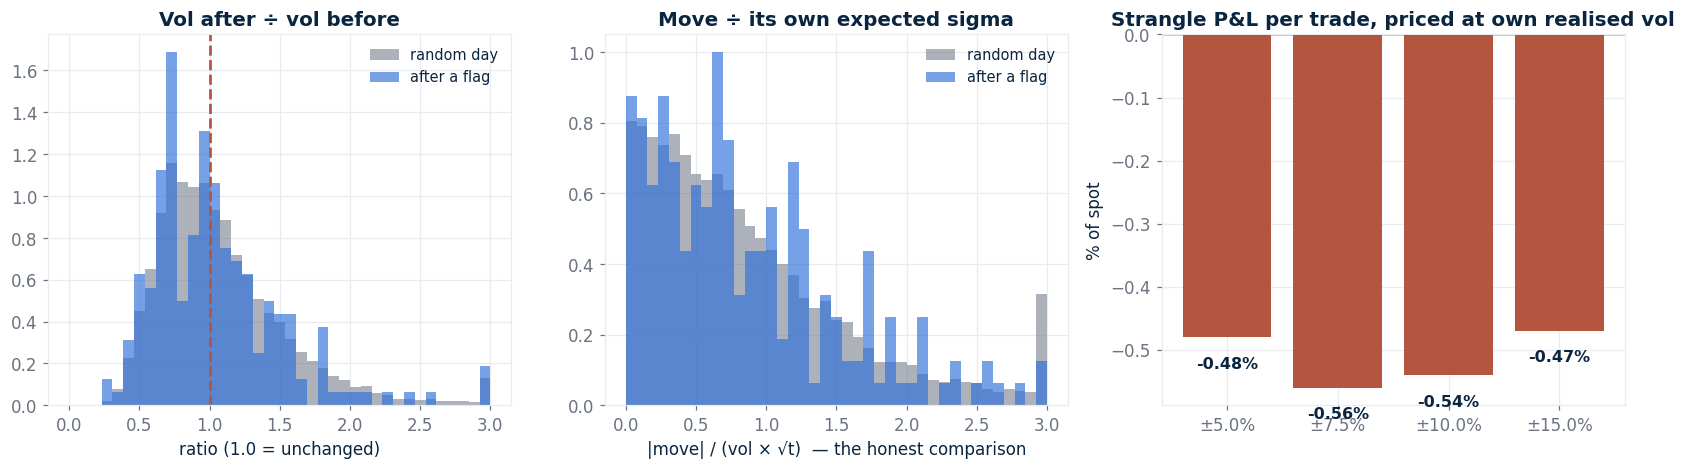

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
ax = axes[0]
_b = np.linspace(0, 3, 40)
ax.hist(CTRL["ratio"].clip(0, 3), bins=_b, density=True, color=GREY,
        alpha=0.55, label="random day")
ax.hist(FLAG["ratio"].clip(0, 3), bins=_b, density=True, color=BLUE,
        alpha=0.65, label="after a flag")
ax.axvline(1.0, color=RED, lw=1.8, ls="--")
ax.set_title("Vol after ÷ vol before")
ax.set_xlabel("ratio (1.0 = unchanged)")
ax.legend(frameon=False, fontsize=9.5)

ax = axes[1]
_b2 = np.linspace(0, 3, 40)
ax.hist(CTRL["z"].clip(0, 3), bins=_b2, density=True, color=GREY,
        alpha=0.55, label="random day")
ax.hist(FLAG["z"].clip(0, 3), bins=_b2, density=True, color=BLUE,
        alpha=0.65, label="after a flag")
ax.set_title("Move ÷ its own expected sigma")
ax.set_xlabel("|move| / (vol × √t)  — the honest comparison")
ax.legend(frameon=False, fontsize=9.5)

ax = axes[2]
_fl = STRANGLE[STRANGLE["group"] == "FLAG"]
_net = [float(v.strip("%+")) for v in _fl["net per trade"]]
ax.bar(_fl["strike"], _net, color=[GREEN if v > 0 else RED for v in _net])
ax.axhline(0, color=NAVY, lw=1.6)
for i, v in enumerate(_net):
    ax.text(i, v - 0.03, f"{v:+.2f}%", ha="center", va="top", fontsize=10.5,
            fontweight="bold")
ax.set_title("Strangle P&L per trade, priced at own realised vol")
ax.set_ylabel("% of spot")
fig.tight_layout()
plt.show()

## 7.4 Verdict: no tradeable volatility strategy here

All three tests point the same way, and the last one prices it.

* **Vol does not expand** after a flag (p ≈ 0.94 against).
* **Moves are bigger only because the names were already volatile** —
  normalised by their own expected sigma, flags and controls are
  indistinguishable (p ≈ 0.42).
* **A strangle loses at every strike**: roughly −0.5% of spot per
  trade at ±5% through ±15%, and that is BEFORE the variance risk
  premium, before spreads and before commission. Across 208 flags
  that is about −1.0× spot notional in total.

The **breakeven implied vol** makes the size of the problem concrete:
at ±5% strikes you would need to buy the strangle at roughly 35% IV
or cheaper, while the flagged names' own trailing realised vol
averages about 36% — and listed options on names like these
habitually trade several points ABOVE realised. You would need to buy
volatility meaningfully cheaper than it has actually been delivered,
on exactly the names where everyone can see it is elevated.

**The control group is the sanity check that this is the model and
not the arithmetic.** Priced the same way, control days come out at
roughly zero (+0.05% to +0.11%), which is what pricing realised
outcomes at realised vol should produce. The flags are worse than
that, not merely unprofitable in absolute terms.

**What would change the answer.** A cheaper expression of the same
view — a directional trade taken only when the inflection agrees with
a GET IN or GET OUT, so you are not paying for both tails — is not
tested here and is not ruled out by it. And the whole section rests
on 208 flags in a store still missing 2023–25; it should be re-run
after the backfill before the door is closed for good.

**What does NOT change the answer:** moving the strikes. The loss is
flat across ±5% to ±15%, which is the signature of a mispriced view
rather than a badly chosen structure.

## What this notebook does NOT claim

* **It does not claim a production win.** Nothing here has been
  adopted, and the coverage gap means a gain measured on 2021–22 plus
  2026 may not survive the backfill.
* **It does not claim the labels are the right ones.** Three gradings
  were built because the desk named three different things it wanted;
  which of them is worth shipping is a judgement the numbers inform
  and do not make.
* **It does not claim the AI layer adds accuracy.** It is explicitly
  forbidden from forecasting. If it is adopted it should be measured
  on whether readers make better decisions with it, which is not a
  quantity this notebook can produce.

---
# §8 — Can the posts ALONE call GET IN / GET OUT? (added 2026-08-14)

**Desk request.** *"i dont like how this project uses prices as a
feature to predict prices (i feel like thats a bit fundamentally
wrong). can you investigate for the get in and get out symbols if its
possible to use only the post factors to predict with relatively good
accuracy?"* — with the purity level set to **fully price-blind**: no
price features AND no price-based phase gate. Price appears in exactly
one place: the LABELS (an episode is a price event — that is the
target, not an input).

Price enters the shipped pair at two doors, and this section closes
both:

| door | shipped pair | this section |
|---|---|---|
| features | 9 crowd + **2 price** | 13 crowd (9 + the 4 price-free §3 extras), **0 price** |
| trigger | phase gate from the 120d boom bar (**price**) routes IN vs OUT | **no gate** — either side may fire any day |

**Unlike the rest of this notebook, this section fed a shipped
change**: the EXPERIMENTAL "posts only" trigger mode on the dashboard
(columns `*_xp` in the desk store, cuts frozen in the desk record's
`experimental_price_blind` block, `EUPHORIA_XP_ENABLED` in
`src/config.py`). The mode is clearly labelled and never the default —
the numbers below are why.

In [36]:
from analytics.euphoria_phases import (inflection_features,        # noqa: E402
                                       INFLECTION_EXTRA_FEATURES,
                                       run_tournament_entry)
from src.config import EUPHORIA_FA_BUDGET_PER_IY                   # noqa: E402

# the price-blind candidate frame: coverage gate only, NO
# attach_price_features (that call also DROPS rows lacking a judgeable
# price feature - 58,698 days here vs 58,630 with the price pair)
XPC = inflection_features(mld.candidate_frame(frame))
XP_BANK = list(mld.ML_BANK) + INFLECTION_EXTRA_FEATURES
print(f"{len(XPC):,} price-blind name-days · bank {len(mld.ML_BANK)} crowd"
      f" + {len(INFLECTION_EXTRA_FEATURES)} extras = {len(XP_BANK)}")

XP_RES = {}
for _hd, _lb, _md in (("get_in", "y_onset", "onset"),
                      ("get_out", "y_top", "top")):
    for _tag, _mk, _bk in (("ens_crowd9", mld.make_ens_fit, mld.ML_BANK),
                           ("ens_xp13", mld.make_ens_fit, XP_BANK),
                           ("logit_xp13", mld.make_logit_fit, XP_BANK),
                           ("gbm_xp13", mld.make_gbm_fit, XP_BANK)):
        _t0 = time.time()
        _wf = run_tournament_entry(XPC, episodes, _bk, _lb, _md,
                                   _mk(_lb), EUPHORIA_FA_BUDGET_PER_IY,
                                   chooser=mld.choose_threshold_f1)
        mld._summarise_entry(_wf, sym_by, pxmap, _md)
        XP_RES.setdefault(_hd, {})[_tag] = {
            k: _wf.get(k) for k in
            ("ap", "ap_baseline", "auroc", "captured", "detectable",
             "false_alarms", "precision", "median_lead_days",
             "forward_returns", "test_years")}
        _r = XP_RES[_hd][_tag]
        print(f"[{_hd:8s}] {_tag:11s} AP {_r['ap']:.3f} (base "
              f"{_r['ap_baseline']:.3f}) AUROC {_r['auroc']:.3f} cap "
              f"{_r['captured']}/{_r['detectable']} FA "
              f"{_r['false_alarms']}  ({time.time() - _t0:.0f}s)")

# the shipped reference, read from the stored desk tournament rather
# than re-fitted - the comparison must be against the record the desk
# actually froze
_dkr = json.load(open("data/processed/euphoria_desk_report.json"))
SHIPPED = {h: _dkr["tournament"][h]["ens"] for h in ("get_in", "get_out")}
for _hd in ("get_in", "get_out"):
    _s = SHIPPED[_hd]
    print(f"[{_hd:8s}] SHIPPED ens  AP {_s['ap']:.3f} (base "
          f"{_s['ap_baseline']:.3f}) AUROC {_s['auroc']:.3f} cap "
          f"{_s['captured']}/{_s['detectable']} FA {_s['false_alarms']}"
          f"   <- crowd + price, phase-gated")

58,698 price-blind name-days · bank 9 crowd + 4 extras = 13


[get_in  ] ens_crowd9  AP 0.137 (base 0.111) AUROC 0.551 cap 70/198 FA 235  (9s)


[get_in  ] ens_xp13    AP 0.157 (base 0.111) AUROC 0.571 cap 74/198 FA 288  (13s)


[get_in  ] logit_xp13  AP 0.165 (base 0.111) AUROC 0.575 cap 68/198 FA 292  (7s)


[get_in  ] gbm_xp13    AP 0.137 (base 0.111) AUROC 0.547 cap 75/198 FA 265  (8s)


[get_out ] ens_crowd9  AP 0.124 (base 0.104) AUROC 0.549 cap 81/218 FA 531  (9s)


[get_out ] ens_xp13    AP 0.137 (base 0.104) AUROC 0.560 cap 46/218 FA 299  (13s)


[get_out ] logit_xp13  AP 0.133 (base 0.104) AUROC 0.574 cap 50/218 FA 282  (8s)


[get_out ] gbm_xp13    AP 0.126 (base 0.104) AUROC 0.562 cap 51/218 FA 288  (8s)
[get_in  ] SHIPPED ens  AP 0.283 (base 0.111) AUROC 0.750 cap 112/198 FA 112   <- crowd + price, phase-gated
[get_out ] SHIPPED ens  AP 0.255 (base 0.104) AUROC 0.717 cap 92/218 FA 165   <- crowd + price, phase-gated


## 8.1 Reading the table

Three findings, in the order they matter.

**1. The four §3 extras help the price-blind heads — the only free
lift on offer.** GET IN AP 0.137 → 0.157–0.165 and AUROC 0.551 →
~0.57 just by letting the IN/OUT heads see the four price-free
features built for the inflection head (attention instability, mood
dispersion, the attention×mood interaction, source-breadth change).
GET OUT moves the same direction. They cost nothing and were already
in the store.

**2. By the desk's own selection rule, LOGIT wins the price-blind
bank.** One family for both heads, combined test AP lift, ties →
AUROC: logit 0.165 + 0.133 = 0.298 vs ens 0.157 + 0.137 = 0.294 —
a near-tie that AUROC breaks in logit's favour on BOTH heads (0.575 /
0.574). That is the family frozen into the experimental record.

**3. But the honest headline is the gap to the shipped pair.** AP
lift over base is ~1.4–1.5× price-blind against ~2.5× shipped; AUROC
~0.57 against 0.75 / 0.72. Removing price costs roughly two thirds of
the model's ranking edge — which is exactly what P05b's noise chart
said from the other direction (the price pair is the single input the
model leans on hardest). "Relatively good accuracy" is not what these
numbers show; "measurably better than coin-flip, honestly labelled"
is.

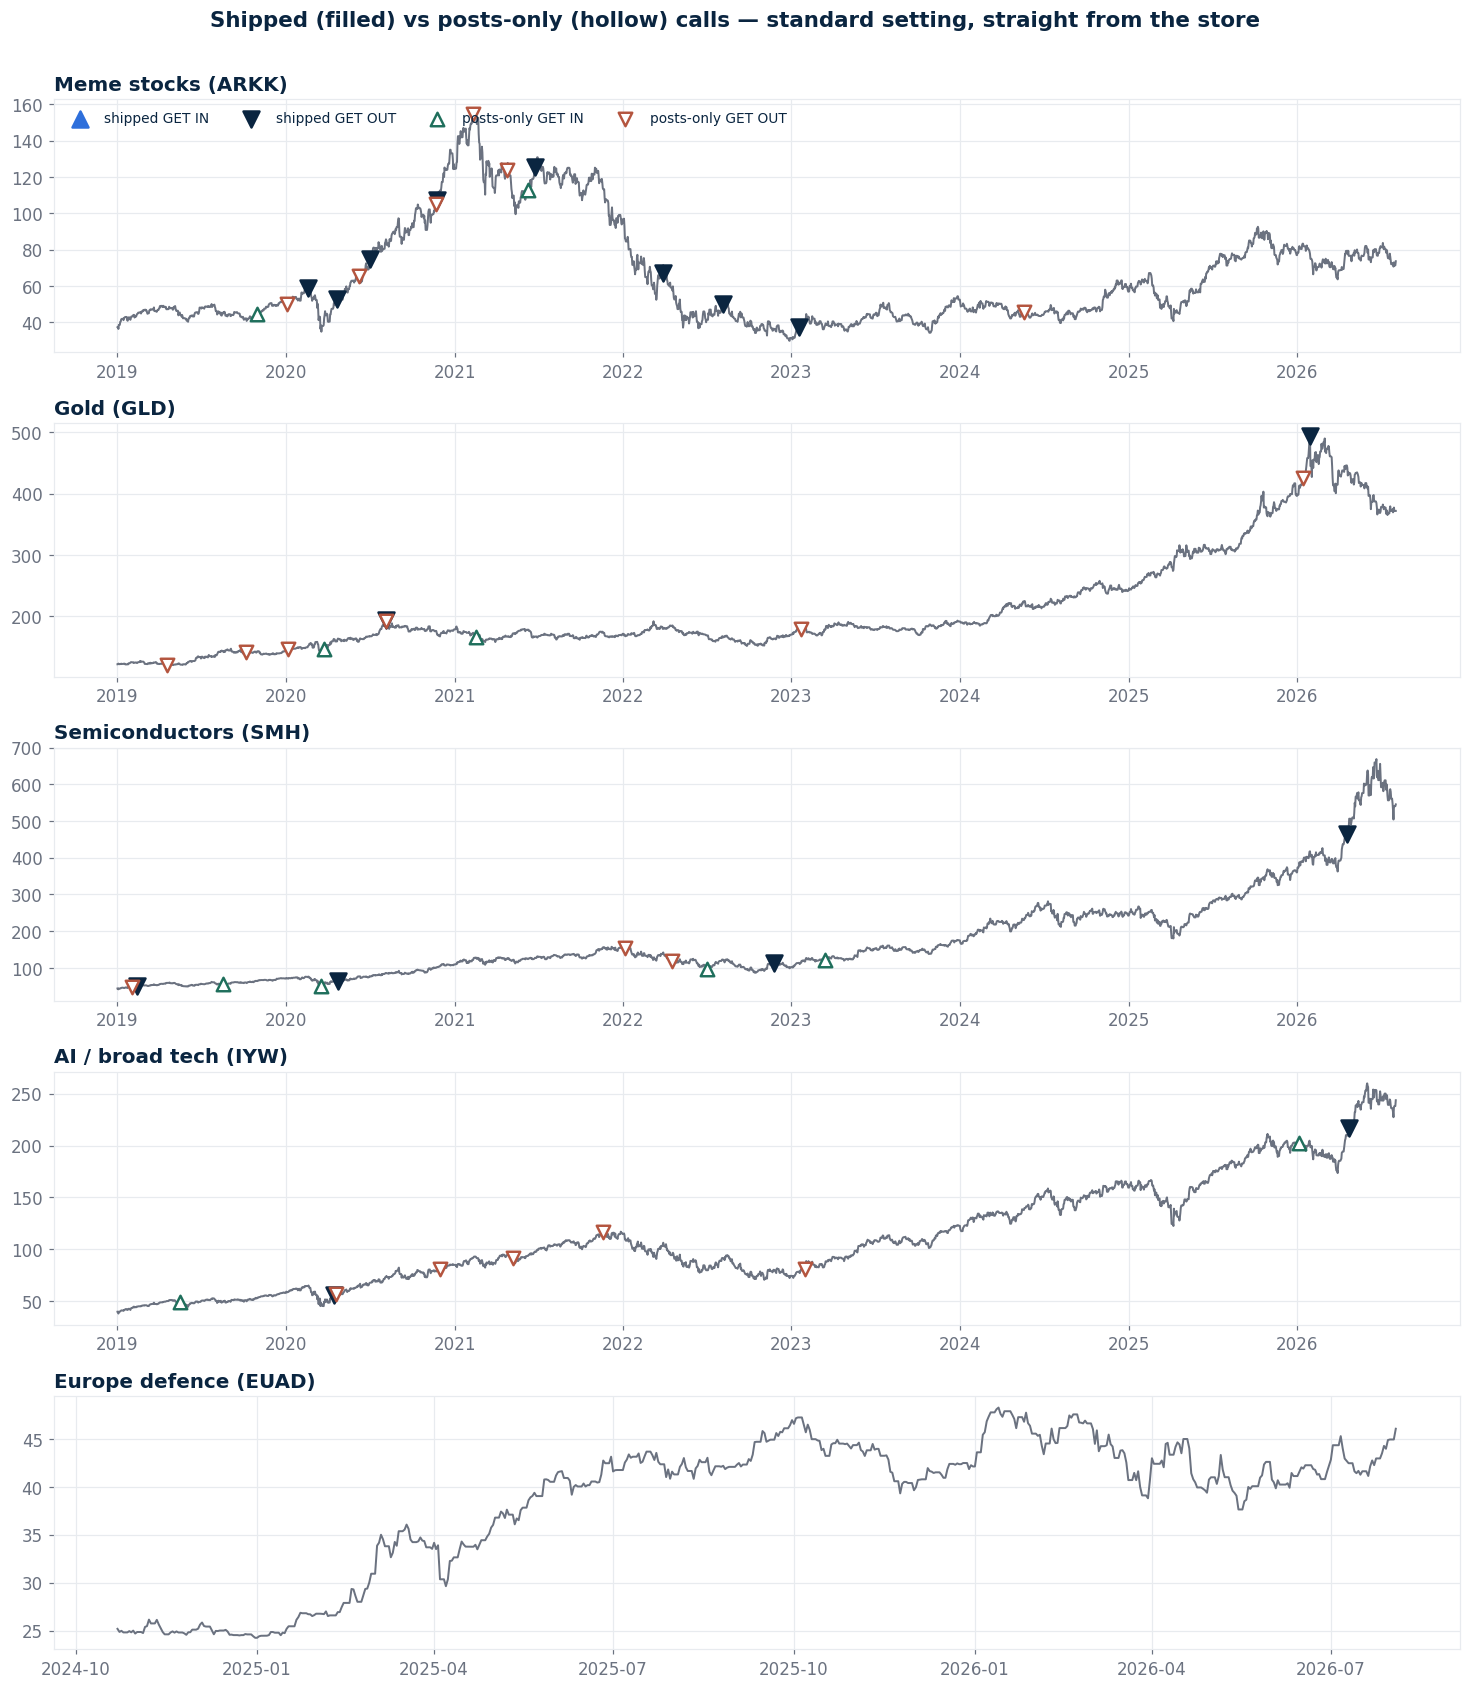

In [37]:
# ---- 8.2 what the experimental trigger actually fires on the five
# names (from the STORE - these are the very columns the dashboard
# mode reads, standard setting)
DK8 = pd.read_parquet("data/processed/euphoria_desk.parquet")
DK8["date"] = pd.to_datetime(DK8["date"])
fig, axes = plt.subplots(len(SHOW), 1, figsize=(13.5, 3.05 * len(SHOW)))
for ax, (nm, sym, nice) in zip(np.atleast_1d(axes), SHOW):
    px = pxmap.get(sym)
    if px is None or not len(px.dropna()):
        ax.text(0.5, 0.5, f"{nice} ({sym}) — no price series",
                ha="center", va="center", transform=ax.transAxes,
                color=GREY)
        continue
    px = px.dropna().loc["2019-01-01":]
    ax.plot(px.index, px.values, color=GREY, lw=1.3)
    g = DK8[DK8["name"] == nm]
    for col, mark, colr, lab in (
            ("get_in_strict", "^", BLUE, "shipped GET IN"),
            ("get_out_strict", "v", NAVY, "shipped GET OUT"),
            ("get_in_xp_strict", "^", GREEN, "posts-only GET IN"),
            ("get_out_xp_strict", "v", RED, "posts-only GET OUT")):
        d = g.loc[g[col].astype(bool), "date"]
        d = d[(d >= px.index.min()) & (d <= px.index.max())]
        y = px.reindex(d, method="ffill")
        filled = "xp" not in col
        ax.scatter(d, y.values, marker=mark, s=110 if filled else 78,
                   color=colr if filled else "white",
                   edgecolor=colr, linewidth=1.6, zorder=5,
                   label=lab)
    ax.set_title(f"{nice} ({sym})", loc="left")
axes[0].legend(loc="upper left", fontsize=9, ncol=4, frameon=False)
fig.suptitle("Shipped (filled) vs posts-only (hollow) calls — standard "
             "setting, straight from the store", y=1.005,
             fontweight="bold", fontsize=14)
fig.tight_layout()
plt.show()

In [38]:
RESULTS["sections"]["price_blind"] = {
    "results": XP_RES, "shipped_reference": SHIPPED,
    "winner": "logit on the 13-feature price-blind bank",
    "selection_rule": ("desk rule: one family both heads, combined AP "
                       "lift, ties -> AUROC"),
}
with open(os.path.join(OUT, "nb08_price_blind.json"), "w",
          encoding="utf-8") as fh:
    json.dump({
        "question": ("can the posts alone (no price features, no price "
                     "gate) call GET IN / GET OUT?"),
        "protocol": ("walk-forward run_tournament_entry on the "
                     "coverage-only candidate frame WITHOUT "
                     "attach_price_features; F1 chooser; banks: 9 crowd "
                     "vs 9 + the 4 price-free inflection extras"),
        "results": XP_RES, "shipped_reference": SHIPPED,
        "winner": "logit_xp13",
        "selection_rule": ("one family for both heads, combined test AP "
                           "lift, ties -> AUROC"),
        "verdict": ("AP lift ~1.4-1.5x over base vs ~2.5x shipped; "
                    "AUROC ~0.57 vs ~0.73-0.75. Shipped only as the "
                    "clearly-labelled EXPERIMENTAL dashboard mode "
                    "(*_xp columns), never the default."),
    }, fh, indent=1, default=str)
print(f"wrote {OUT}/nb08_price_blind.json")

wrote docs/research/nb08_price_blind.json


## 8.3 Verdict, and what shipped

**Can the posts alone do it?** They carry real information — every
price-blind variant beats its base rate walk-forward, and the §3
extras push the ranking to AUROC ≈ 0.57 — but they are nowhere near
the shipped pair, and the deficit is structural, not a tuning gap:
P04 already showed no single crowd measure beats 0.55 alone, and
P05b showed the crowd block as a whole is worth about half the
model's edge. The crowd tells you *that* a name is hot; price tells
you *where in the arc* you are standing. Remove the second and IN vs
OUT becomes genuinely harder to distinguish.

**What shipped from this section** (the one part of this notebook
that became production):

* `euphoria_desk.parquet` gains `in_score_xp`, `out_score_xp`,
  `get_in_xp[_strict]`, `get_out_xp[_strict]` — logit on the
  13-feature price-blind bank, shaped trigger with NO phase gate,
  same F1/F0.5 frozen-cut contract as the desk pair.
* The dashboard gains a **trigger** switch: *Shipped (crowd + price)*
  vs *Experimental (posts only)*, default shipped. In experimental
  mode every score, marker, threshold, watchlist row and the
  readiness dial read the `_xp` columns — and with no phase gate the
  dial shows whichever side is nearer to firing.
* The frozen cuts live in the desk record's
  `experimental_price_blind` block (self-healing on the next research
  pass, like every other frozen number here); the walk-forward
  evidence is `docs/research/nb08_price_blind.json`.

**What this section does NOT claim.** Not that the mode should guide
money — its calls are research context. And the caveat every section
of this notebook carries applies with extra force here: the store is
still missing most of 2023–25, and a crowd-only detector is exactly
the kind of thing a crowd-coverage gap flatters or damns unfairly.
Re-run after the backfill.